# Bayesian Optimization — Function 5 (4D, Improved)

This notebook runs one step of Bayesian Optimization on a **4-dimensional** black-box function.

### Improvements over the original F5 script

| Area | Original | Improved |
|---|---|---|
| **Seed** | None | `np.random.default_rng(42)` |
| **Data path** | Hardcoded Windows path | `pathlib.Path(".")` — portable |
| **Data loading** | Loads all 8 functions, uses only F5 | Loads F5 only |
| **y transform** | None | **Log-transform required** (y spans 0.11 to 1089, ~4 orders of magnitude) |
| **Kernel** | RBF | Matérn ν=2.5 |
| **xi** | Fixed at 0.1 | Adaptive (starts at 0.1, decays) |
| **Sampling** | 50k pure random | 50k Sobol quasi-random (tuned for 4D) |
| **L-BFGS-B starts** | 5 | 12 |
| **Acquisition** | EI only | EI or UCB (switchable) |
| **Structure** | One-shot script | Full BO loop with history tracking |
| **Visualization** | None | 2D slice plots (all 6 dimension pairs) + convergence plot |

## 1. Imports & Configuration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C, WhiteKernel
from scipy.stats import norm, qmc
from scipy.optimize import minimize

# ── SVM: Classify high vs low regions ────────────────────────────────────────
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# ── Neural Network: MC-Dropout surrogate ─────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
rng  = np.random.default_rng(SEED)
torch.manual_seed(SEED)

## 2. Data Loading & Log-Transform

F5's output values span approximately **0.11 to 1089** — a range of roughly 4 orders of magnitude. This causes two serious problems for a standard GP:

1. **Poor kernel calibration**: the GP's length scales and amplitude are optimised to fit the large values, making it nearly blind to structure near the smaller ones
2. **Boundary attraction**: with such a skewed landscape, the acquisition function tends to point toward corners and edges of the domain (as seen in the original output: `[0, 1, 1, 1]`), rather than genuinely promising interior regions

**Solution:** apply `log(y)` before fitting. Since all F5 outputs are strictly positive, a standard log (no epsilon needed) compresses the range from `[0.11, 1089]` to approximately `[-2.2, 6.9]` — well-scaled for a GP.

When appending new observations in the BO loop, apply the same `np.log(y_new)` transform before adding to `y_obs_log`.

In [2]:
# ── Portable data loading ─────────────────────────────────────────────────────
# Place initial_inputs.npy / initial_outputs.npy next to this notebook,
# OR change DATA_DIR to wherever the F5 data lives.
DATA_DIR = Path("C:\\Users\\fakep\\OneDrive\\Bureau\\CAPSTONE\\function_5\\")    # <-- edit if needed

X = np.load(DATA_DIR / "initial_inputs.npy")
y = np.load(DATA_DIR / "initial_outputs.npy")

n_dim = X.shape[1]
print(f"Loaded {len(y)} observations, {n_dim} dimensions.")
print(f"Raw y range     : [{y.min():.4f}, {y.max():.4f}]")

# ── Log-transform ─────────────────────────────────────────────────────────────
# All F5 outputs are strictly positive, so a plain log is safe (no epsilon needed).
y_log = np.log(y)

print(f"Log y range     : [{y_log.min():.4f}, {y_log.max():.4f}]")
print(f"Current best (log-space) : {y_log.max():.6f}  (at index {y_log.argmax()})")
print(f"Current best (raw)       : {y.max():.4f}")

Loaded 20 observations, 4 dimensions.
Raw y range     : [0.1129, 1088.8596]
Log y range     : [-2.1809, 6.9929]
Current best (log-space) : 6.992886  (at index 15)
Current best (raw)       : 1088.8596


## 3. Gaussian Process Model

We use a **Matérn ν=2.5 kernel** instead of the original RBF:
- **RBF** assumes infinite differentiability — overly smooth for most real-world functions
- **Matérn 5/2** assumes only twice differentiability, which generalises better in practice

The GP is fitted on **log-transformed outputs** `y_log`. This means:
- The kernel hyperparameters (length scales, amplitude) are optimised on the compressed, well-scaled log landscape
- The acquisition function operates in log-space, so `y_max` passed to EI is `max(y_log)`, not `max(y)`
- All suggested points are still in the original [0,1]⁴ input space — no back-transformation is needed for inputs

In [3]:
def build_gp(n_dim: int) -> GaussianProcessRegressor:
    kernel = (
        C(1.0, constant_value_bounds=(1e-3, 1e5))
        * Matern(length_scale=[1.0] * n_dim,
                 length_scale_bounds=(1e-3, 1e3),
                 nu=2.5)
        + WhiteKernel(noise_level=1e-5,
                      noise_level_bounds=(1e-7, 1e-1))
    )
    return GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=25,
        alpha=1e-6,
        normalize_y=True,
    )

## 4. Acquisition Functions

Acquisition functions decide **where to sample next** by balancing exploration (uncertain regions) and exploitation (promising regions).

### Expected Improvement (EI)
$$EI(x) = (\mu(x) - y_{max} - \xi) \cdot \Phi(Z) + \sigma(x) \cdot \phi(Z), \quad Z = \frac{\mu(x) - y_{max} - \xi}{\sigma(x)}$$
where `ξ` (xi) controls the exploration-exploitation trade-off. Since the GP is fitted in log-space, `y_max` here is `max(y_log)` and EI scores are in log-space units.

### Upper Confidence Bound (UCB)
$$UCB(x) = \mu(x) + \kappa \cdot \sigma(x)$$

### Adaptive xi
We preserve the original `xi_init=0.1` — appropriate for a 4D space with high variance in outputs. The decay gradually shifts from exploration to exploitation as observations accumulate.

In [4]:
def expected_improvement(X_cand, gp, y_max, xi=0.01):
    """Expected Improvement — higher is better. Operates in log-space for F5."""
    X_cand = np.atleast_2d(X_cand)
    mu, sigma = gp.predict(X_cand, return_std=True)
    sigma = np.maximum(sigma, 1e-8)
    imp   = mu - y_max - xi
    Z     = imp / sigma
    ei    = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma <= 1e-8] = 0.0
    return ei


def upper_confidence_bound(X_cand, gp, kappa=2.576):
    """UCB — higher kappa = more exploration."""
    X_cand = np.atleast_2d(X_cand)
    mu, sigma = gp.predict(X_cand, return_std=True)
    return mu + kappa * sigma


def adaptive_xi(iteration: int, xi_init=0.1, decay=0.85) -> float:
    """Decay xi over iterations for a smooth exploration -> exploitation shift."""
    return max(xi_init * (decay ** iteration), 1e-4)

## 5. Next-Point Suggestion

We find the next point to evaluate in three steps:

1. **Sobol sampling** — generate `n_sobol=50,000` quasi-random candidates in [0,1]⁴. Sobol sequences provide better space coverage than pure random sampling, avoiding the clustering and gaps that caused the original optimizer to collapse to a corner.
2. **Score & rank** — evaluate the acquisition function (in log-space) on all candidates and keep the top `n_best=12`.
3. **Local optimisation** — run L-BFGS-B from each of the top 12 starting points and return the global winner.

> The combination of log-transform + Sobol sampling should eliminate the corner-attraction problem seen in the original (`[0, 1, 1, 1]` suggestion), as the GP will have a more faithful picture of the interior landscape.

In [5]:
def suggest_next_point(
    gp,
    y_max,
    n_dim,
    xi=0.01,
    n_sobol=50_000,   # tuned for 4D
    n_best=12,        # scaled between 3D (10) and 8D (15)
    acq="ei",
    kappa=2.576,
    seed=None,
):
    # Step 1 — Sobol candidates
    sampler = qmc.Sobol(d=n_dim, scramble=True, seed=seed)
    X_cand  = sampler.random(n_sobol)

    # Step 2 — Score
    if acq == "ucb":
        scores = upper_confidence_bound(X_cand, gp, kappa=kappa)
    else:
        scores = expected_improvement(X_cand, gp, y_max, xi=xi)

    # Step 3 — Local optimisation from top-n_best starts
    starts = X_cand[np.argsort(scores)[-n_best:]]
    bounds = [(0, 1)] * n_dim

    if acq == "ucb":
        obj = lambda x: -upper_confidence_bound(x, gp, kappa=kappa).item()
    else:
        obj = lambda x: -expected_improvement(x, gp, y_max, xi=xi).item()

    best_x, best_score = None, -np.inf
    for x0 in starts:
        res = minimize(obj, x0=x0, bounds=bounds, method="L-BFGS-B")
        if -res.fun > best_score:
            best_score = -res.fun
            best_x     = res.x

    return best_x, best_score

## 6. 4D Slice Visualisation Helper

In 4 dimensions there are **6 possible dimension pairs** (4 choose 2). We render all 6 in a 2×3 grid, fixing the two remaining dimensions at `x_next`'s values each time.

The heatmap shows the **acquisition function in log-space** — this is intentional and correct, since the GP is fitted on log-transformed outputs. The colour scale therefore reflects log-space EI, which maps directly to the optimizer's decision-making.

Observed points are projected onto each plane with **opacity proportional to proximity** to the fixed dimension values — points far from the slice plane fade out.

In [6]:
def plot_slices_4d(gp, X_obs, x_next, acq_fn, iteration, acq_label="EI"):
    """
    2x3 grid of acquisition function slice plots covering all 6 dimension pairs.
    Each panel fixes the two non-plotted dimensions at x_next's values.
    Acquisition values are in log-space (GP fitted on log(y)).
    """
    resolution = 100
    grid_1d    = np.linspace(0, 1, resolution)
    G1, G2     = np.meshgrid(grid_1d, grid_1d)
    flat1      = G1.ravel()
    flat2      = G2.ravel()

    dim_labels = ["x1", "x2", "x3", "x4"]
    dim_pairs  = list(combinations(range(4), 2))

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes      = axes.ravel()
    fig.suptitle(
        f"Bayesian Optimization - F5  |  Iteration {iteration}  |  "
        f"Acquisition ({acq_label}, log-space) - all dimension pairs",
        fontsize=12
    )

    for ax, (d0, d1) in zip(axes, dim_pairs):
        fixed_dims = [d for d in range(4) if d not in (d0, d1)]

        X_grid        = np.tile(x_next, (resolution * resolution, 1))
        X_grid[:, d0] = flat1
        X_grid[:, d1] = flat2

        acq_vals = acq_fn(X_grid).reshape(resolution, resolution)

        im = ax.contourf(G1, G2, acq_vals, levels=50, cmap="inferno")
        fig.colorbar(im, ax=ax, shrink=0.85)

        # Project observed points; opacity = proximity to both fixed dim values
        dist   = np.mean([np.abs(X_obs[:, fd] - x_next[fd]) for fd in fixed_dims], axis=0)
        alphas = np.clip(1.0 - dist / 0.3, 0.1, 1.0)
        for xi_obs, yi_obs, a in zip(X_obs[:, d0], X_obs[:, d1], alphas):
            ax.scatter(xi_obs, yi_obs, c="white", edgecolors="black",
                       s=30, alpha=float(a), zorder=5)

        # Suggested next point projection
        ax.scatter(x_next[d0], x_next[d1], c="red", marker="*",
                   s=250, zorder=6, label="Next point")

        fix_str = ", ".join(f"{dim_labels[fd]}={x_next[fd]:.2f}" for fd in fixed_dims)
        ax.set_title(f"{dim_labels[d0]}-{dim_labels[d1]}  ({fix_str})")
        ax.set_xlabel(dim_labels[d0])
        ax.set_ylabel(dim_labels[d1])

    axes[-1].legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.savefig(f"bo_f5_iter_{iteration:03d}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 7. Bayesian Optimization Loop

The full BO loop follows this cycle each iteration:

```
Fit GP (log-space)  ->  Compute xi  ->  Maximise acquisition  ->  Suggest x_next
         ^                                                                |
         +---- Append (x_next, log(y_new)) to dataset  <----------------+
                   (you evaluate y_new externally, then log-transform)
```

**To use this loop:**
1. Run the cell — it will print the suggested point and render the 6-panel slice plot
2. Evaluate the real function at `x_next` to get `y_new`
3. Uncomment the lines under `PLUG YOUR EVALUATOR HERE`
4. Set `N_ITER > 1` and re-run for multi-step optimization

> **Critical:** always apply `np.log(y_new)` before appending to `y_obs_log`. Adding raw y values would corrupt the log-space model. The convergence plot below shows both log-space and raw-space best values for readability.

C:\Users\fakep\AppData\Local\Temp\ipykernel_27236\1024251737.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   1  |  xi = 0.10000  |  acq = EI
  Current best y (log)          : 6.992886
  ✅ Suggested x CAPSTONE       : 0.570757-0.789564-0.817427-1.0
  🎯 Suggested x                : [0.570757, 0.789564, 0.817427, 1.0]
  📈 Acq. score                 : 0.274318


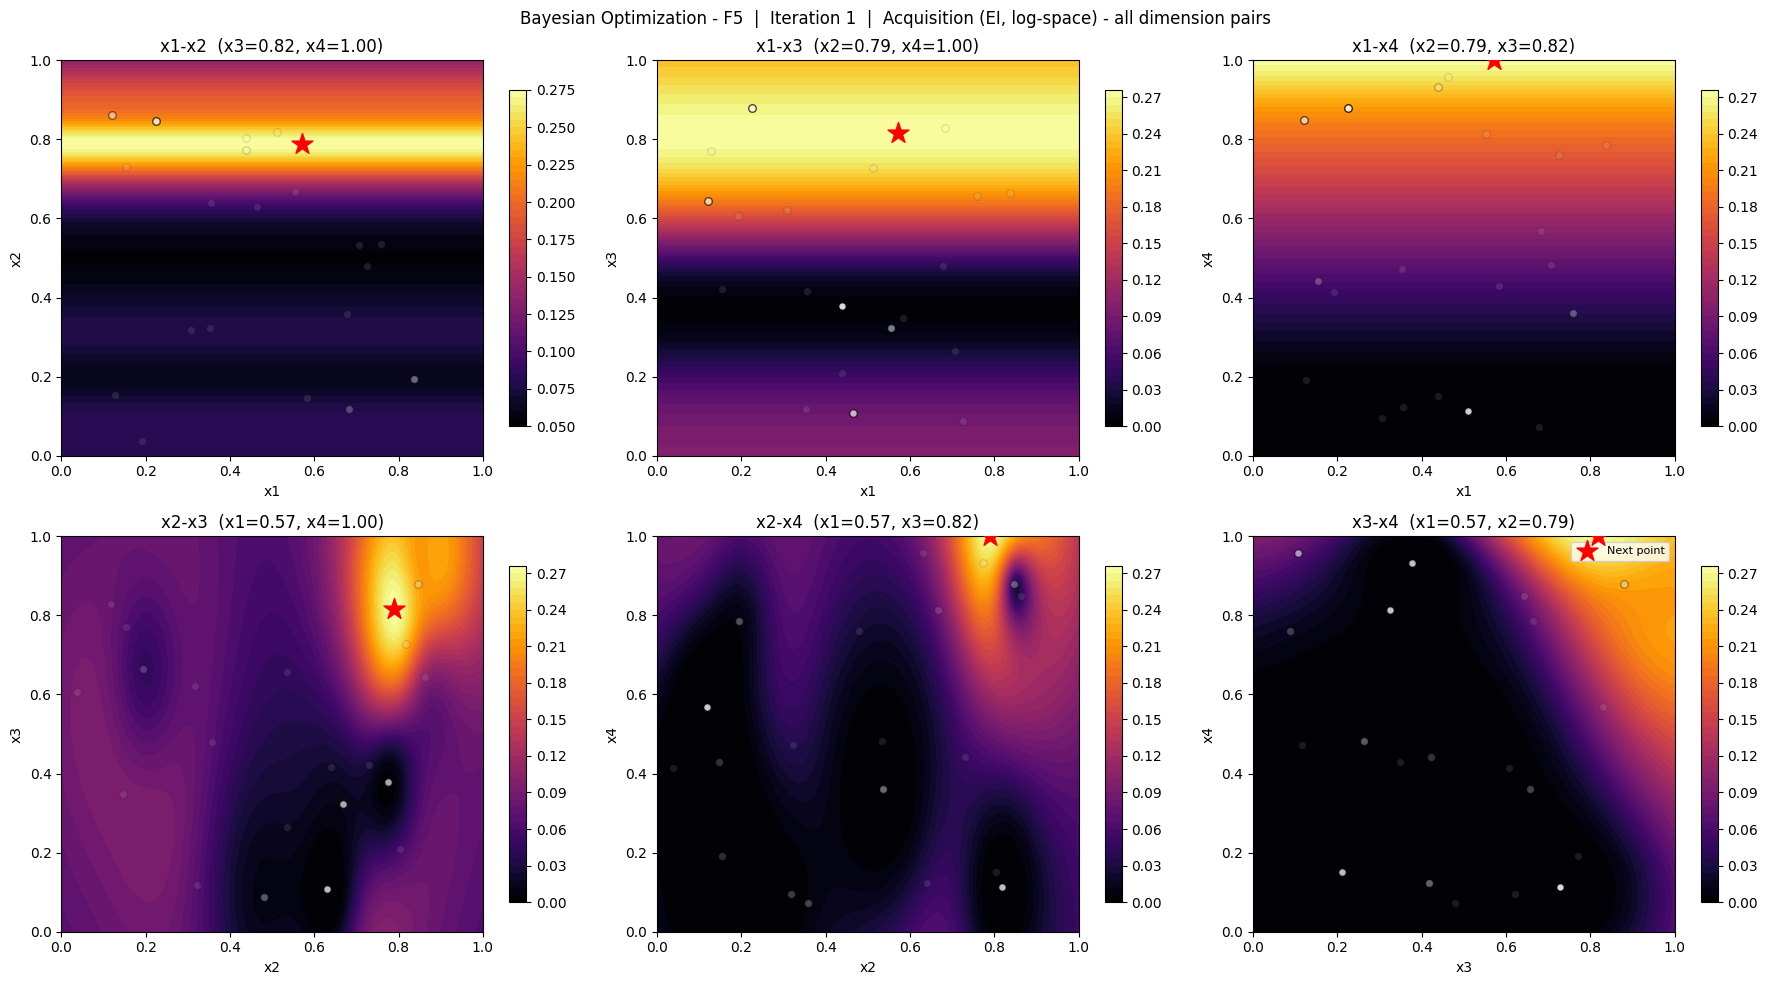

C:\Users\fakep\AppData\Local\Temp\ipykernel_27236\1024251737.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   2  |  xi = 0.08500  |  acq = EI
  Current best y (log)          : 8.398518
  ✅ Suggested x CAPSTONE       : 0.0-0.0-0.0-1.0
  🎯 Suggested x                : [0.0, 0.0, 0.0, 1.0]
  📈 Acq. score                 : 0.850980


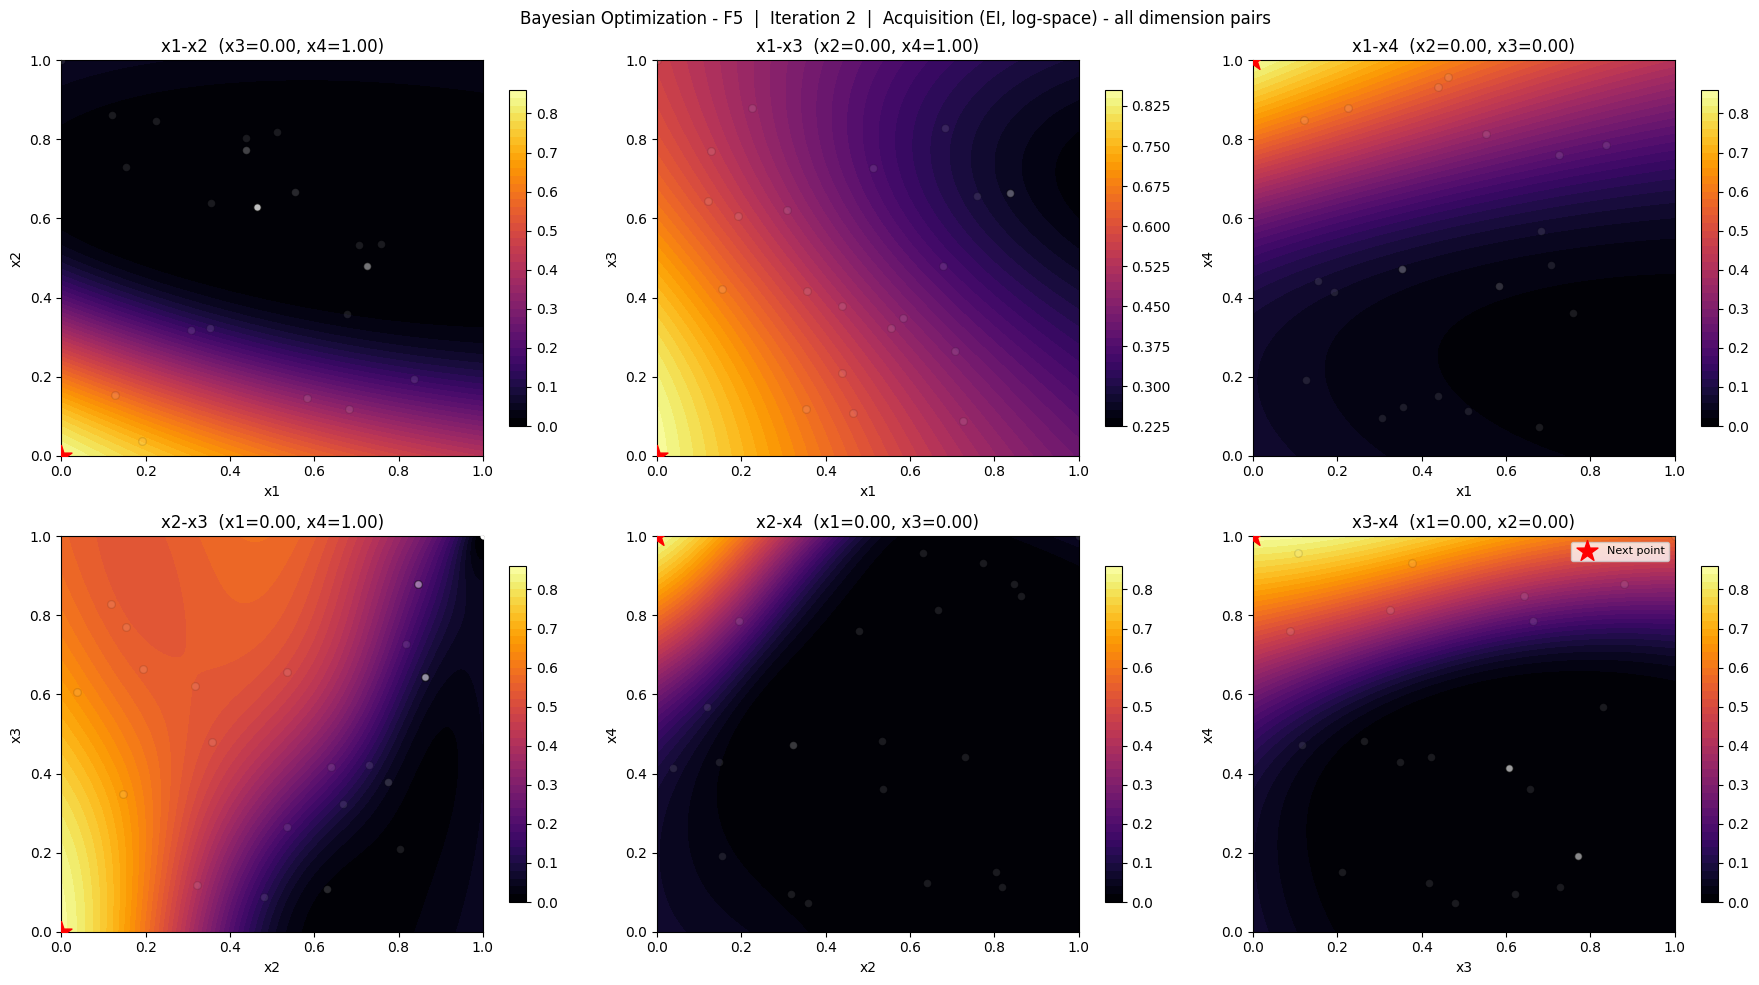

C:\Users\fakep\AppData\Local\Temp\ipykernel_27236\1024251737.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   3  |  xi = 0.07225  |  acq = EI
  Current best y (log)          : 8.398518
  ✅ Suggested x CAPSTONE       : 0.0-0.493454-1.0-1.0
  🎯 Suggested x                : [0.0, 0.493454, 1.0, 1.0]
  📈 Acq. score                 : 0.393492


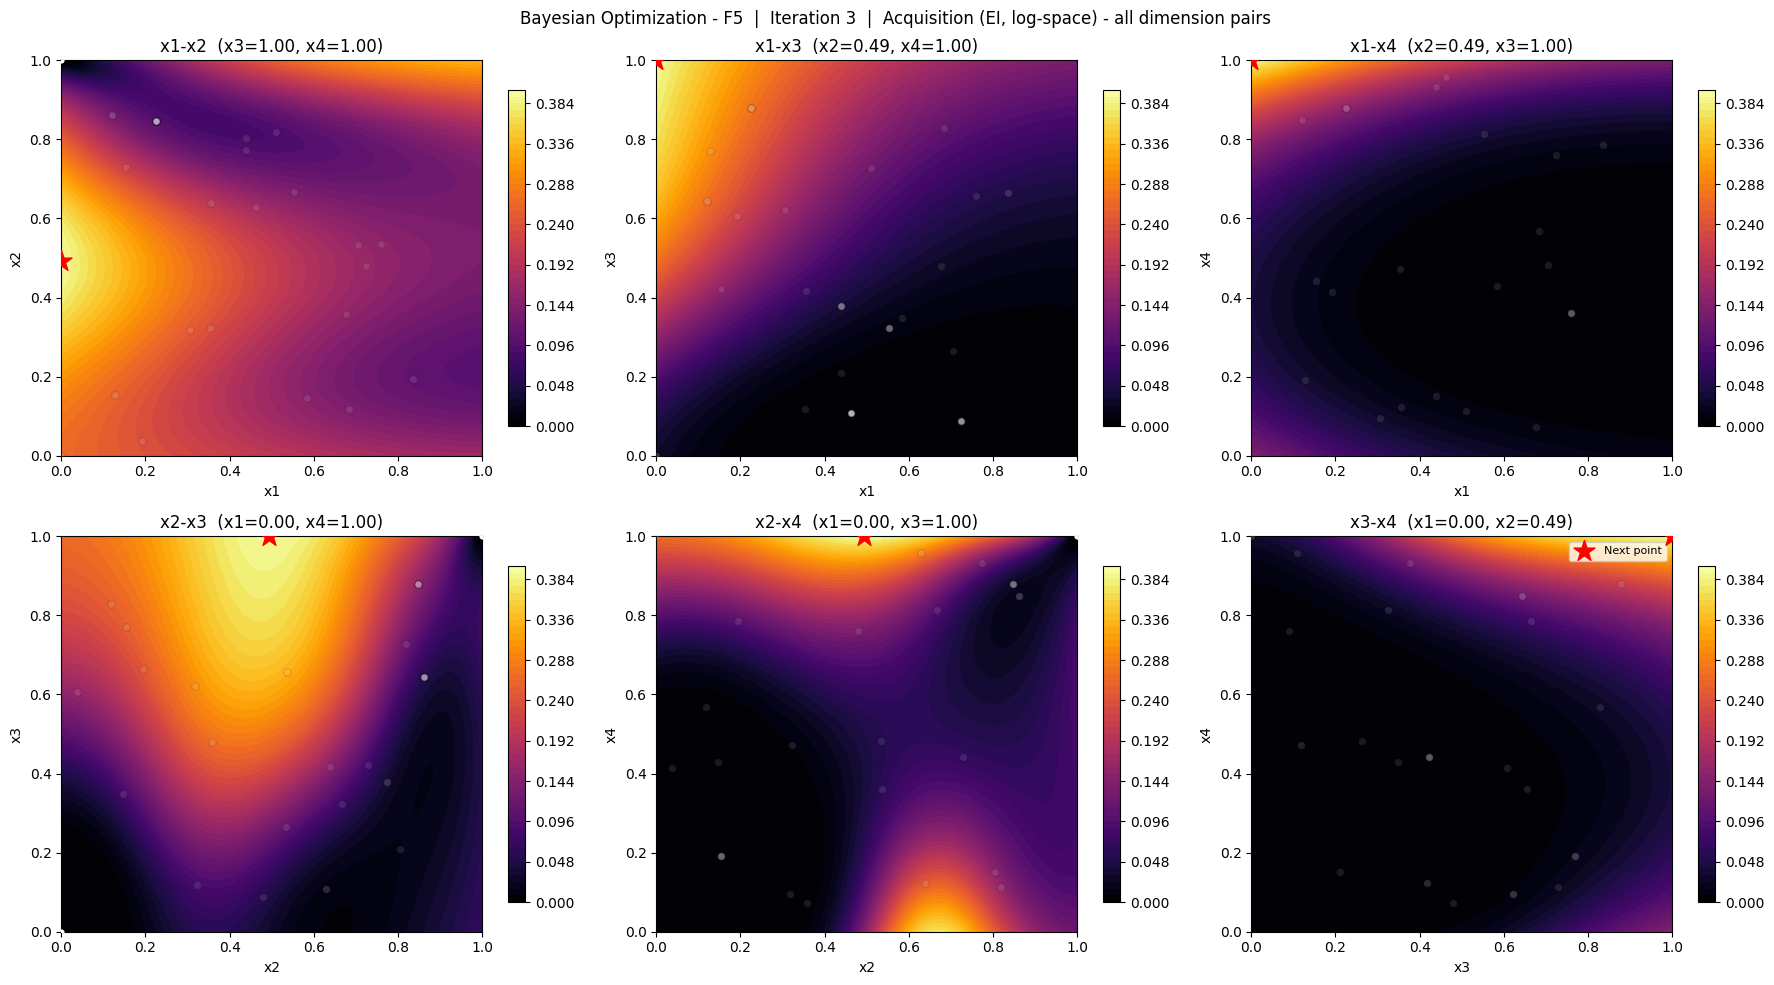

C:\Users\fakep\AppData\Local\Temp\ipykernel_27236\1024251737.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   4  |  xi = 0.06141  |  acq = EI
  Current best y (log)          : 8.398518
  ✅ Suggested x CAPSTONE       : 0.0-0.671047-1.0-0.0
  🎯 Suggested x                : [0.0, 0.671047, 1.0, 0.0]
  📈 Acq. score                 : 0.384505


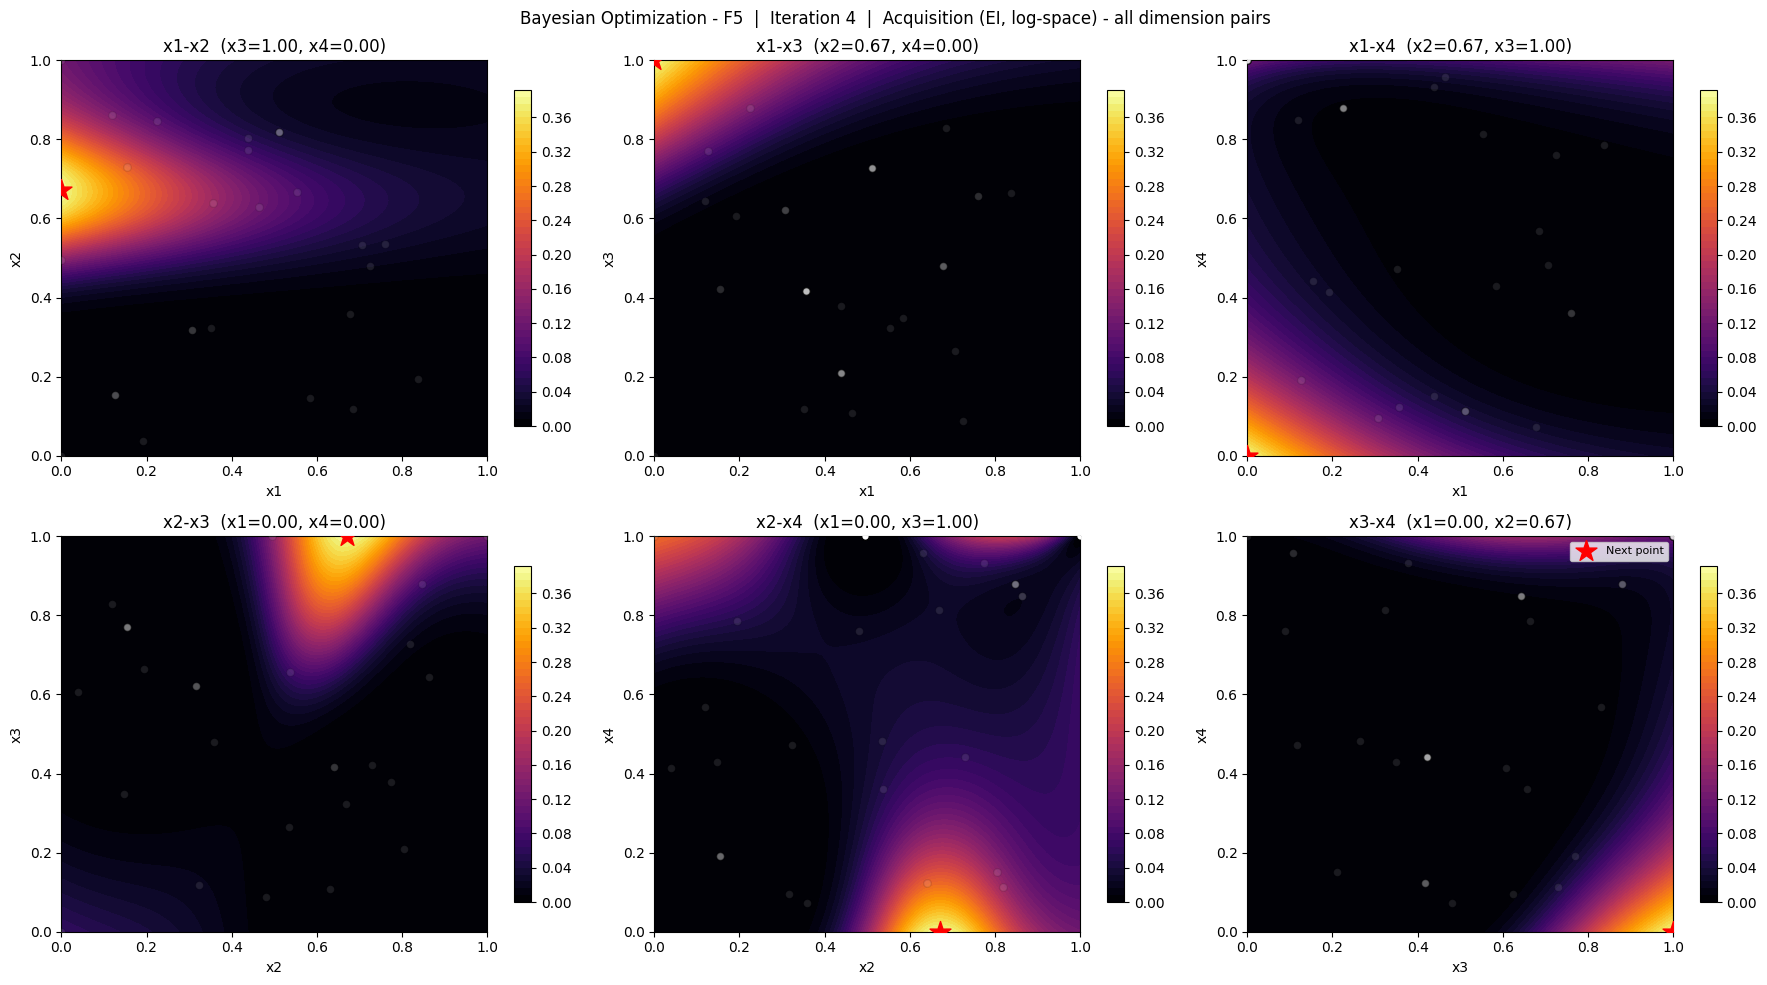

C:\Users\fakep\AppData\Local\Temp\ipykernel_27236\1024251737.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   5  |  xi = 0.05220  |  acq = EI
  Current best y (log)          : 8.398518
  ✅ Suggested x CAPSTONE       : 1.0-1.0-1.0-1.0
  🎯 Suggested x                : [1.0, 1.0, 1.0, 1.0]
  📈 Acq. score                 : 0.271155


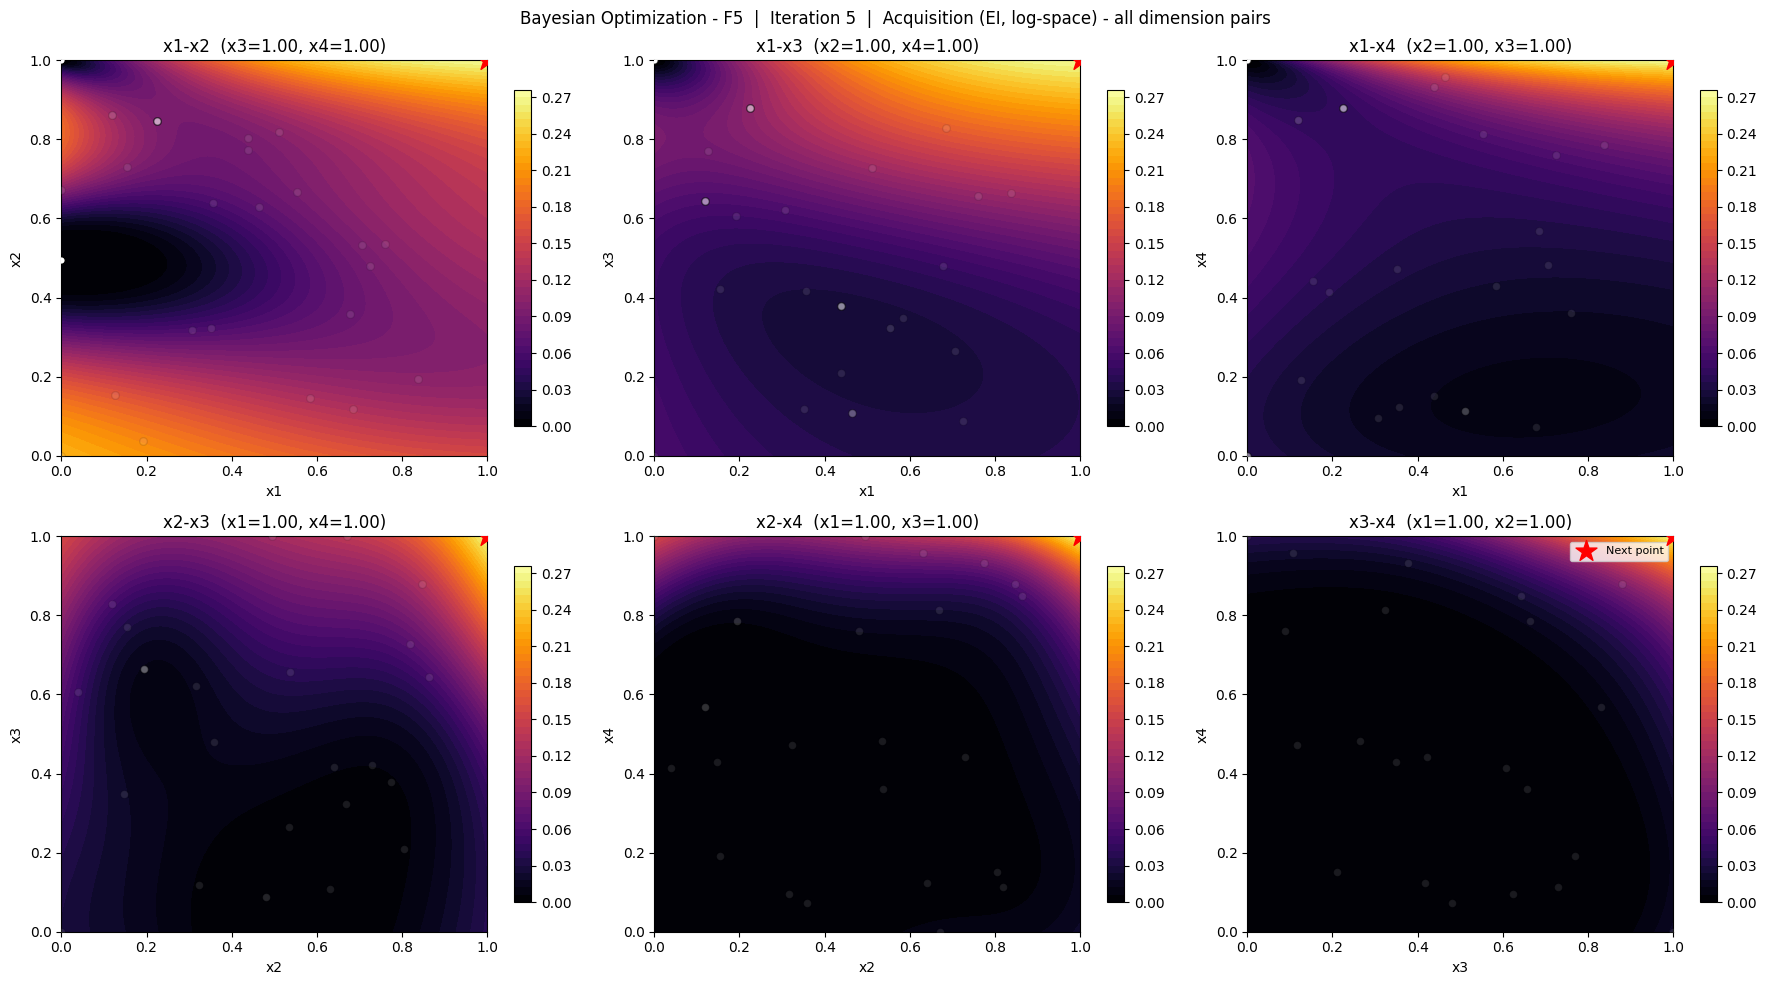

C:\Users\fakep\AppData\Local\Temp\ipykernel_27236\1024251737.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   6  |  xi = 0.04437  |  acq = EI
  Current best y (log)          : 9.066757
  ✅ Suggested x CAPSTONE       : 1.0-1.0-1.0-1.0
  🎯 Suggested x                : [1.0, 1.0, 1.0, 1.0]
  📈 Acq. score                 : 0.133575


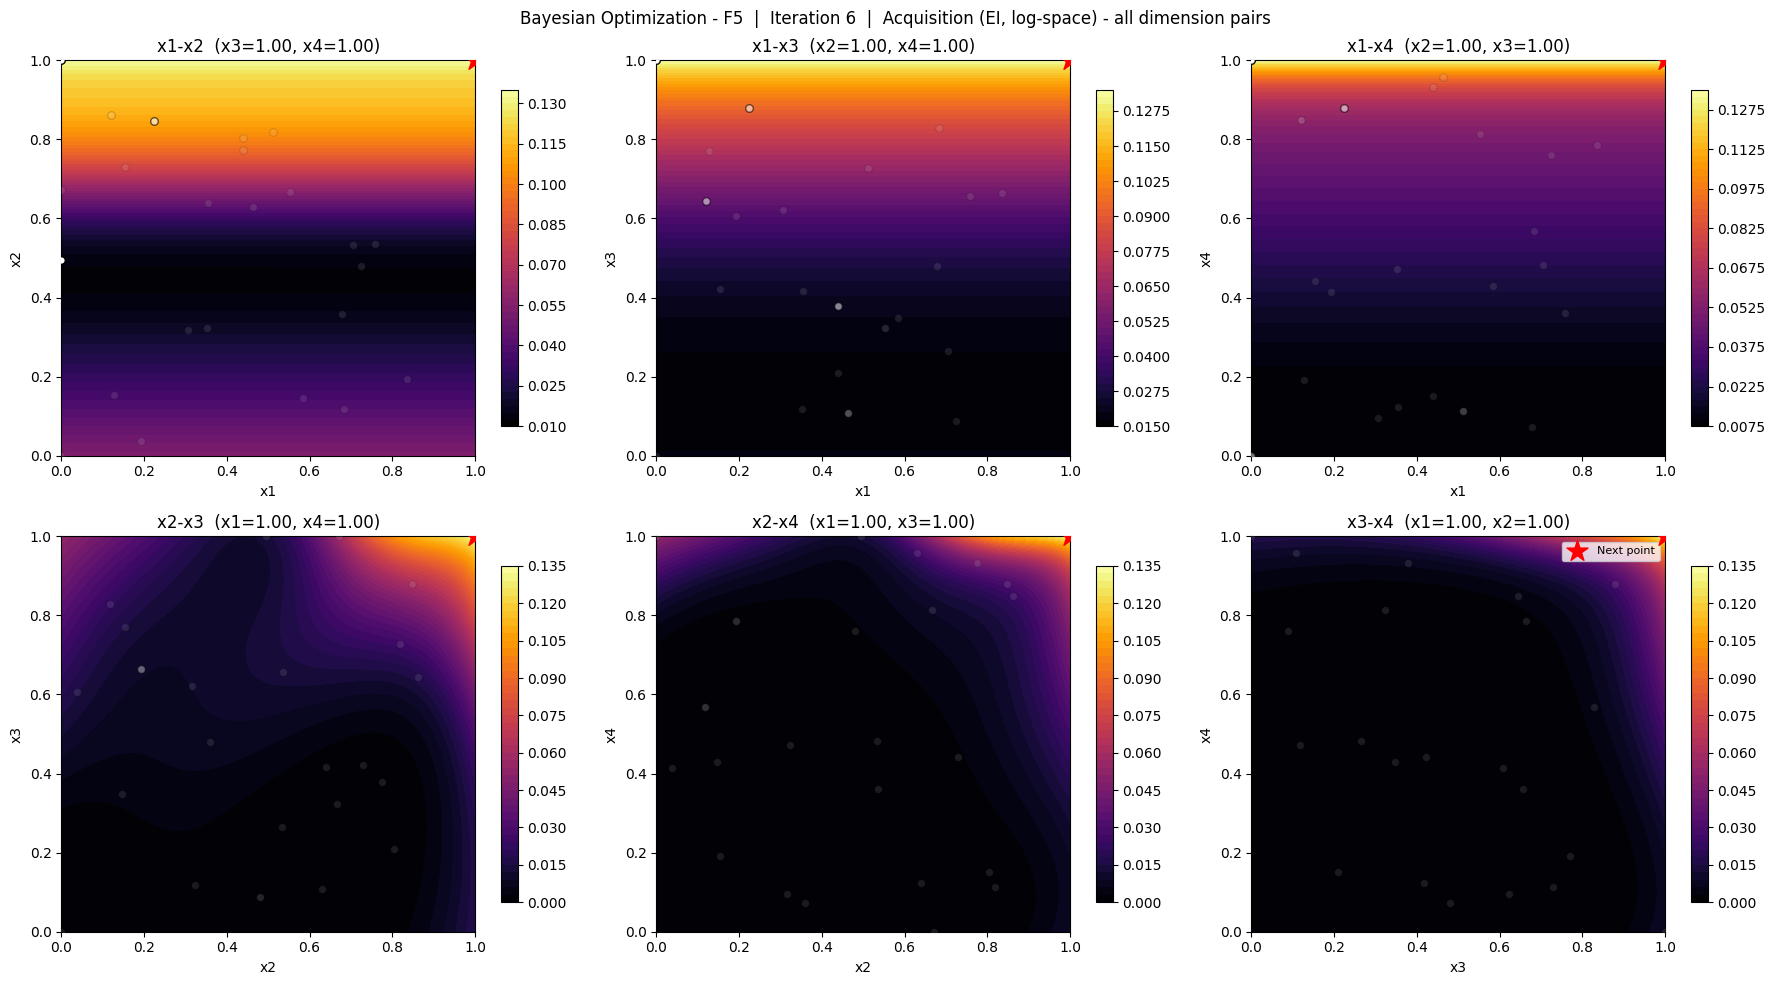

C:\Users\fakep\AppData\Local\Temp\ipykernel_27236\1024251737.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   7  |  xi = 0.03771  |  acq = EI
  Current best y (log)          : 9.066757
  ✅ Suggested x CAPSTONE       : 1.0-1.0-1.0-0.795576
  🎯 Suggested x                : [1.0, 1.0, 1.0, 0.795576]
  📈 Acq. score                 : 0.171363


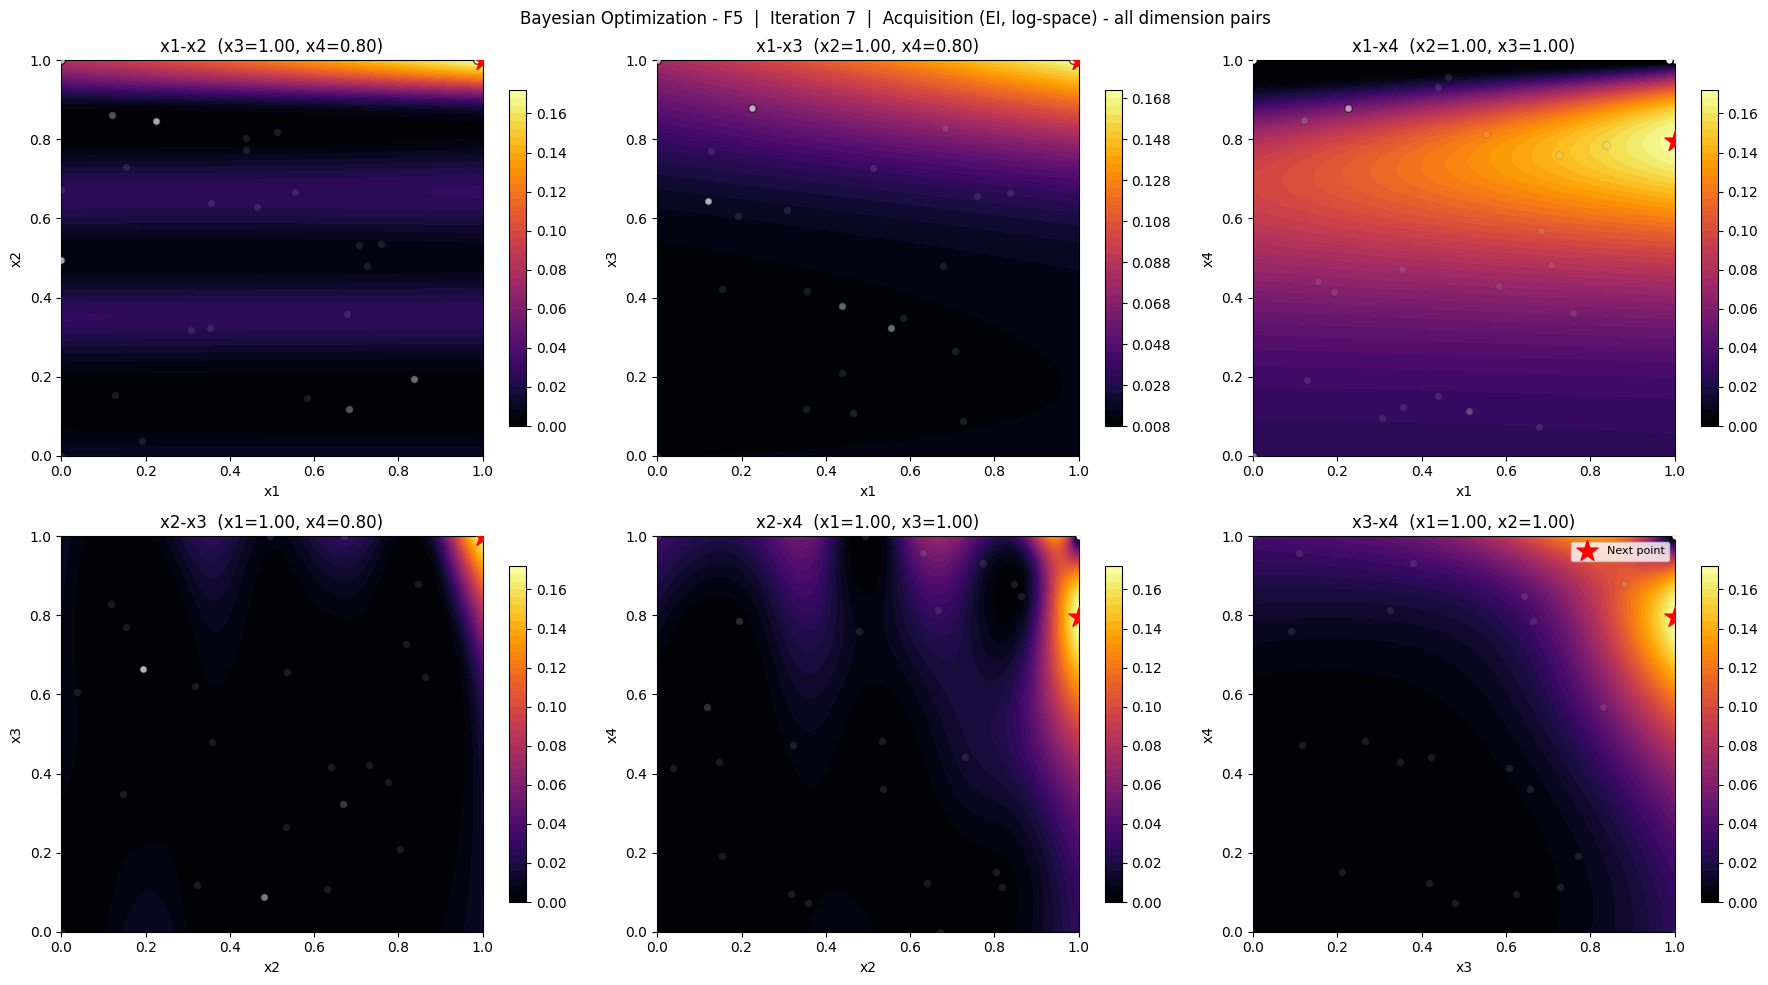

C:\Users\fakep\AppData\Local\Temp\ipykernel_27236\1024251737.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   8  |  xi = 0.03206  |  acq = EI
  Current best y (log)          : 9.066757
  ✅ Suggested x CAPSTONE       : 1.0-1.0-1.0-0.781437
  🎯 Suggested x                : [1.0, 1.0, 1.0, 0.781437]
  📈 Acq. score                 : 0.173163


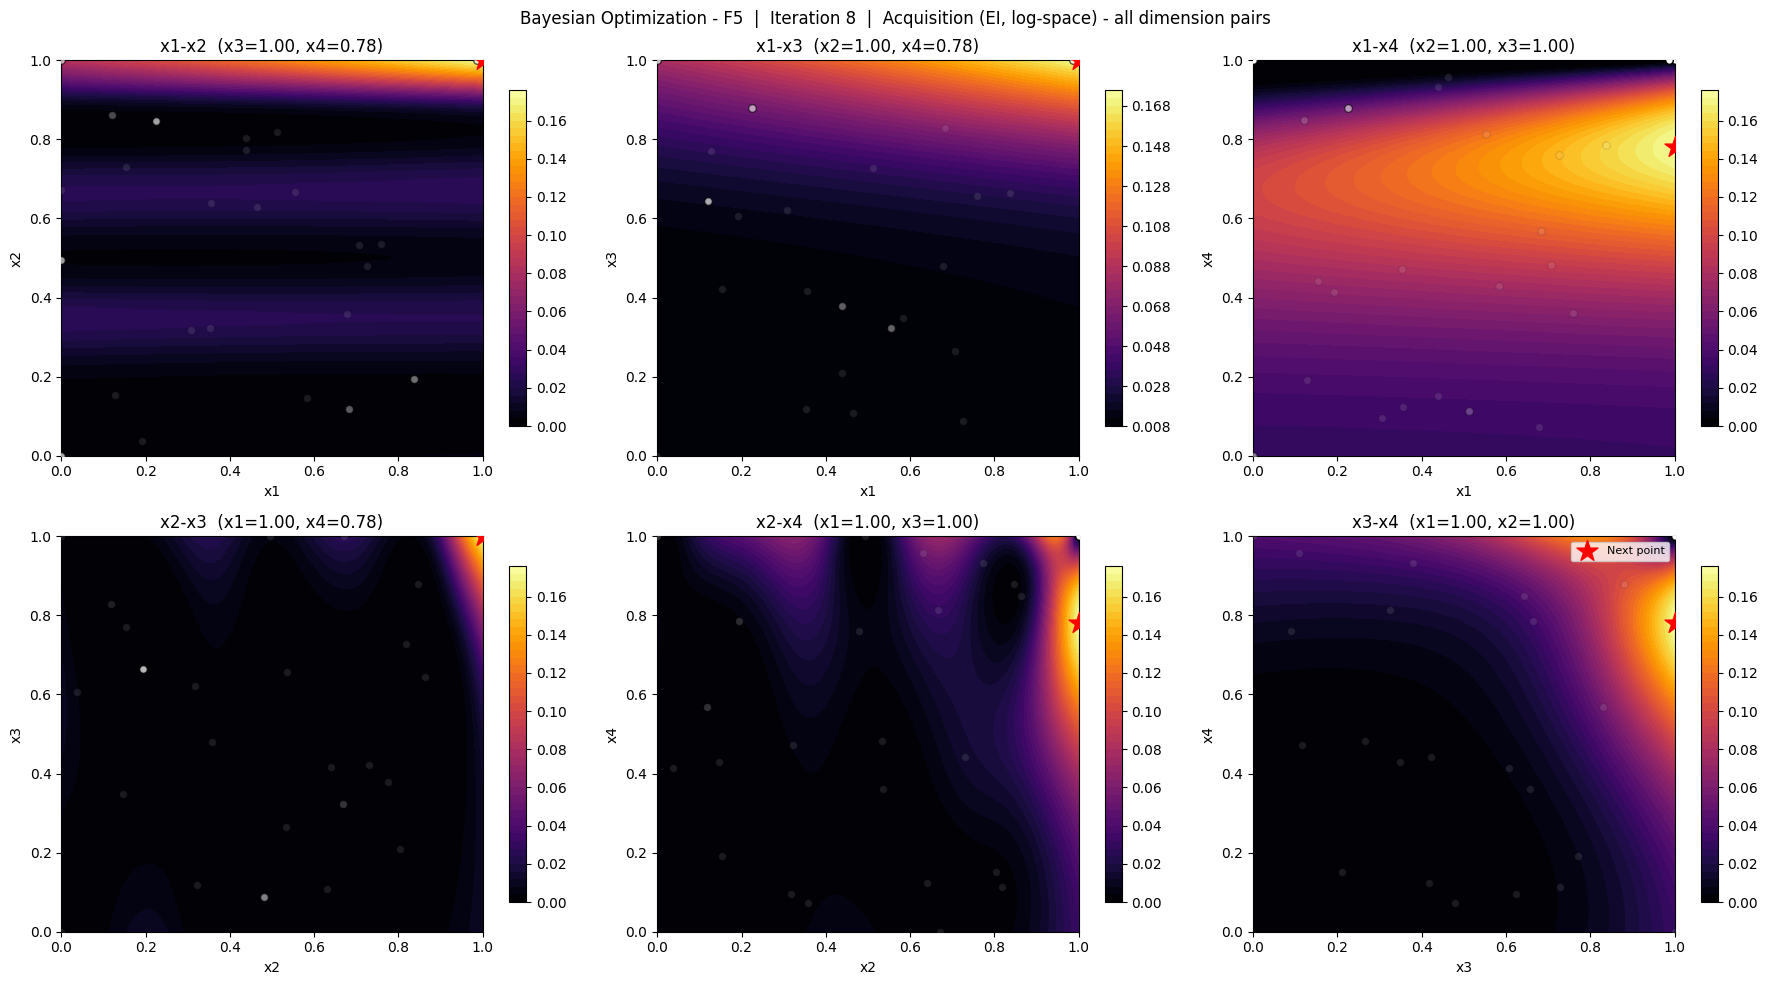

C:\Users\fakep\AppData\Local\Temp\ipykernel_27236\1024251737.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   9  |  xi = 0.02725  |  acq = EI
  Current best y (log)          : 9.066757
  ✅ Suggested x CAPSTONE       : 1.0-1.0-0.978265-0.878994
  🎯 Suggested x                : [1.0, 1.0, 0.978265, 0.878994]
  📈 Acq. score                 : 0.255986


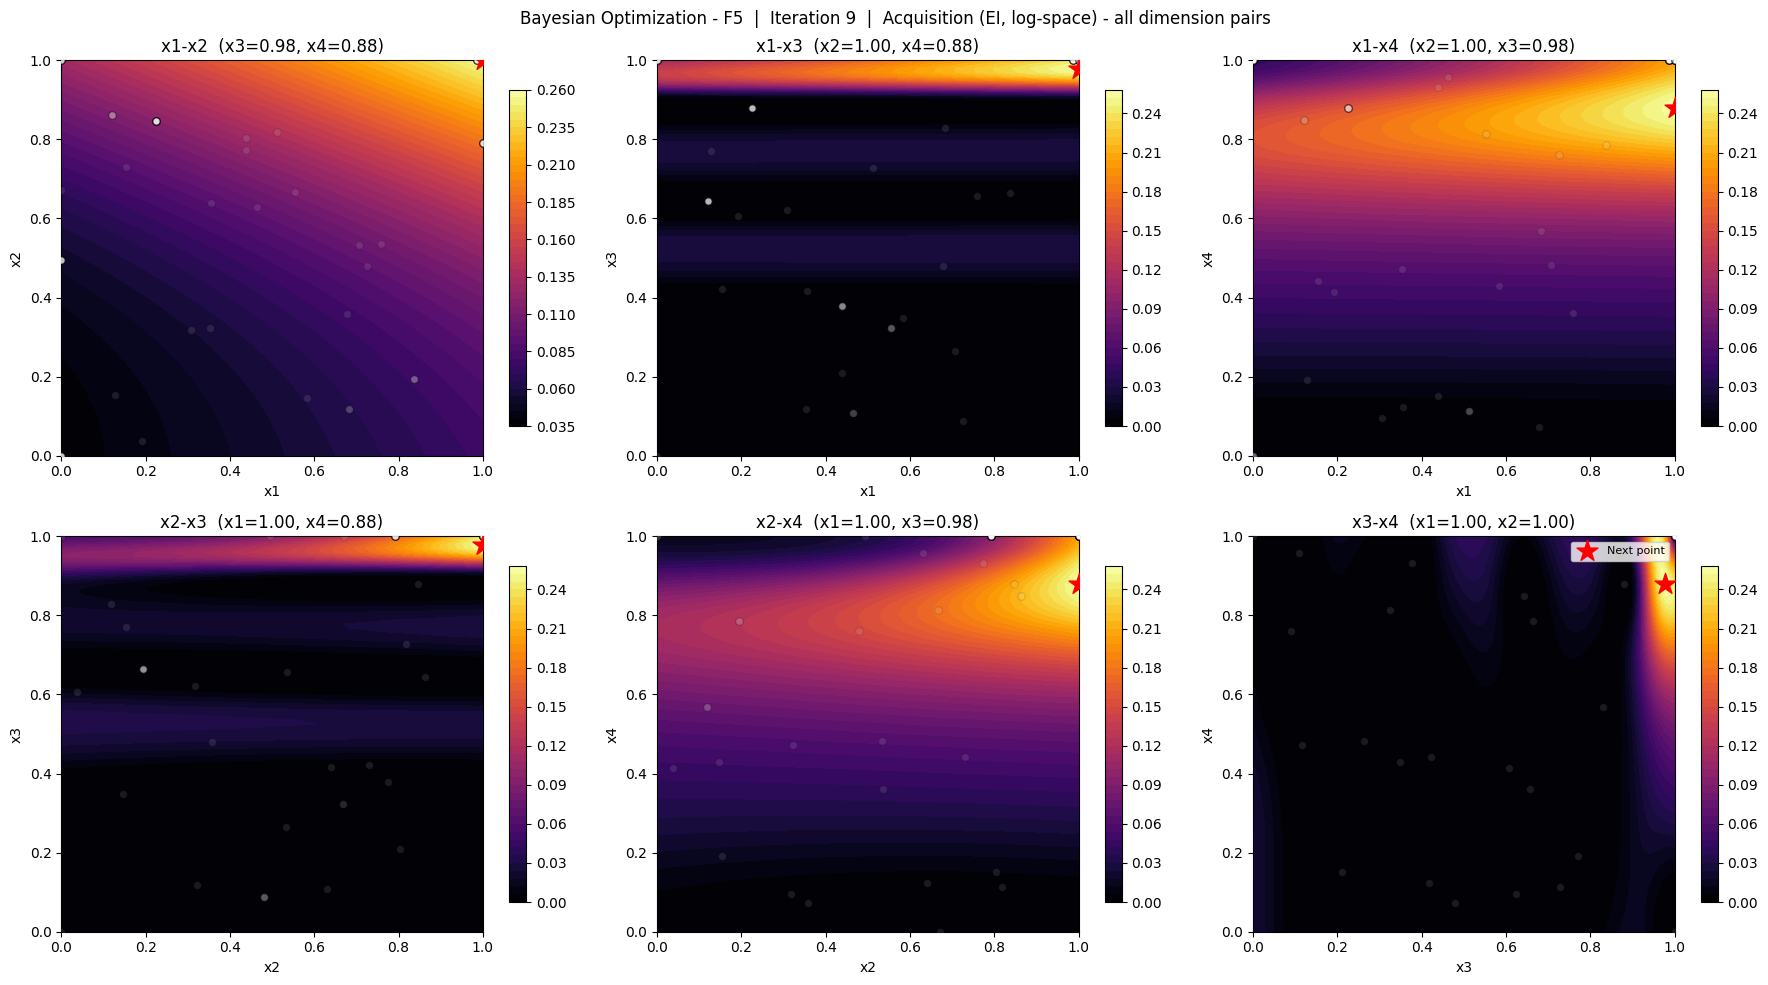

C:\Users\fakep\AppData\Local\Temp\ipykernel_27236\1024251737.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration  10  |  xi = 0.02316  |  acq = EI
  Current best y (log)          : 9.066757
  ✅ Suggested x CAPSTONE       : 1.0-1.0-0.960172-1.0
  🎯 Suggested x                : [1.0, 1.0, 0.960172, 1.0]
  📈 Acq. score                 : 0.236832


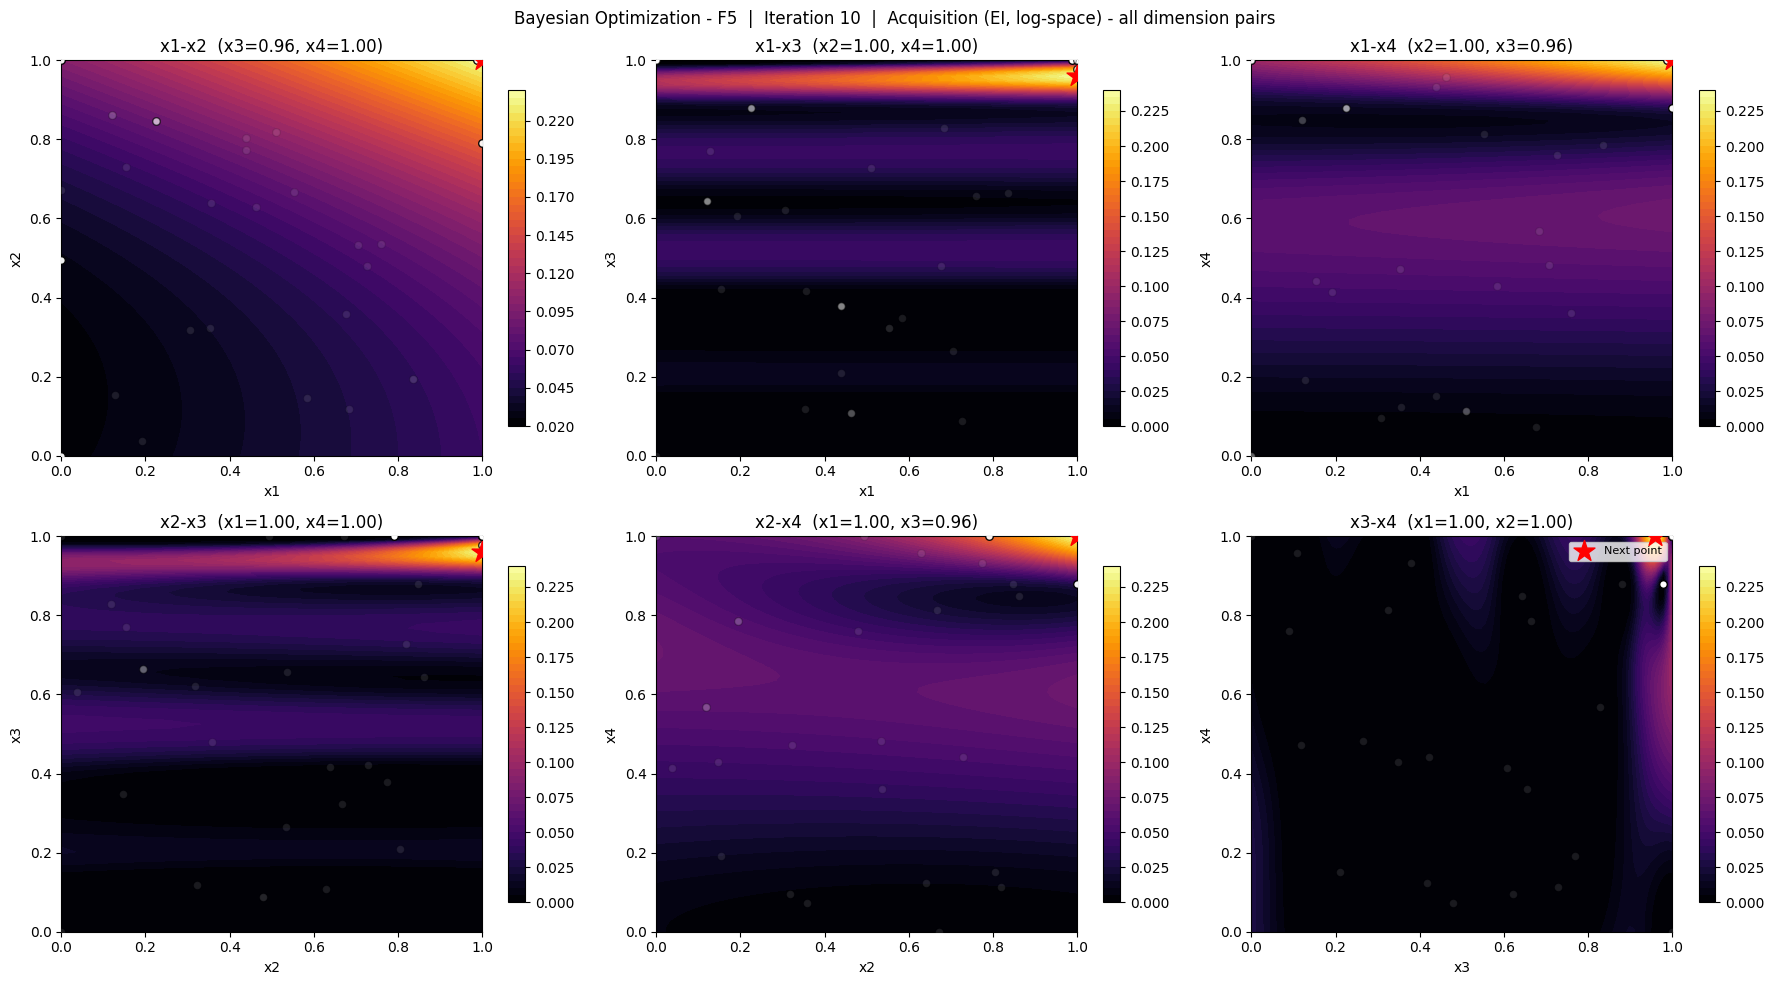

C:\Users\fakep\AppData\Local\Temp\ipykernel_27236\1024251737.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration  11  |  xi = 0.01969  |  acq = EI
  Current best y (log)          : 9.066757
  ✅ Suggested x CAPSTONE       : 1.0-0.0-1.0-1.0
  🎯 Suggested x                : [1.0, 0.0, 1.0, 1.0]
  📈 Acq. score                 : 0.097268


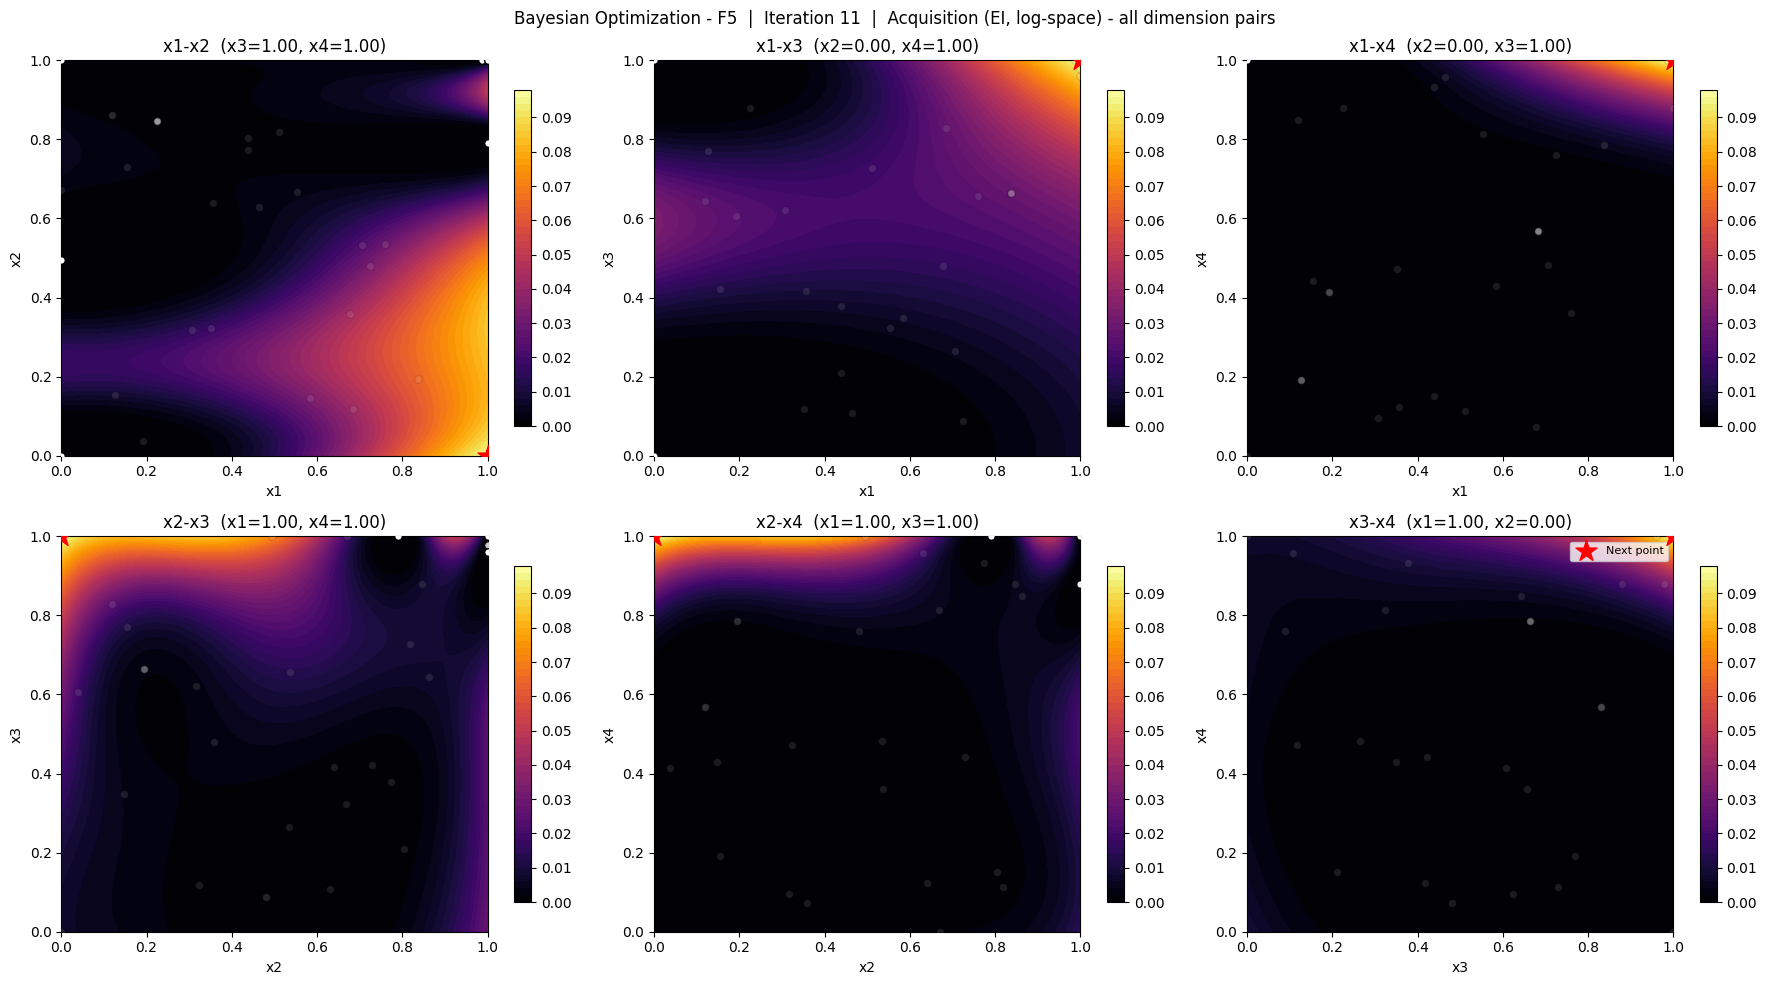

C:\Users\fakep\AppData\Local\Temp\ipykernel_27236\1024251737.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration  12  |  xi = 0.01673  |  acq = EI
  Current best y (log)          : 9.066757
  ✅ Suggested x CAPSTONE       : 1.0-0.0-1.0-0.66768
  🎯 Suggested x                : [1.0, 0.0, 1.0, 0.66768]
  📈 Acq. score                 : 0.100396


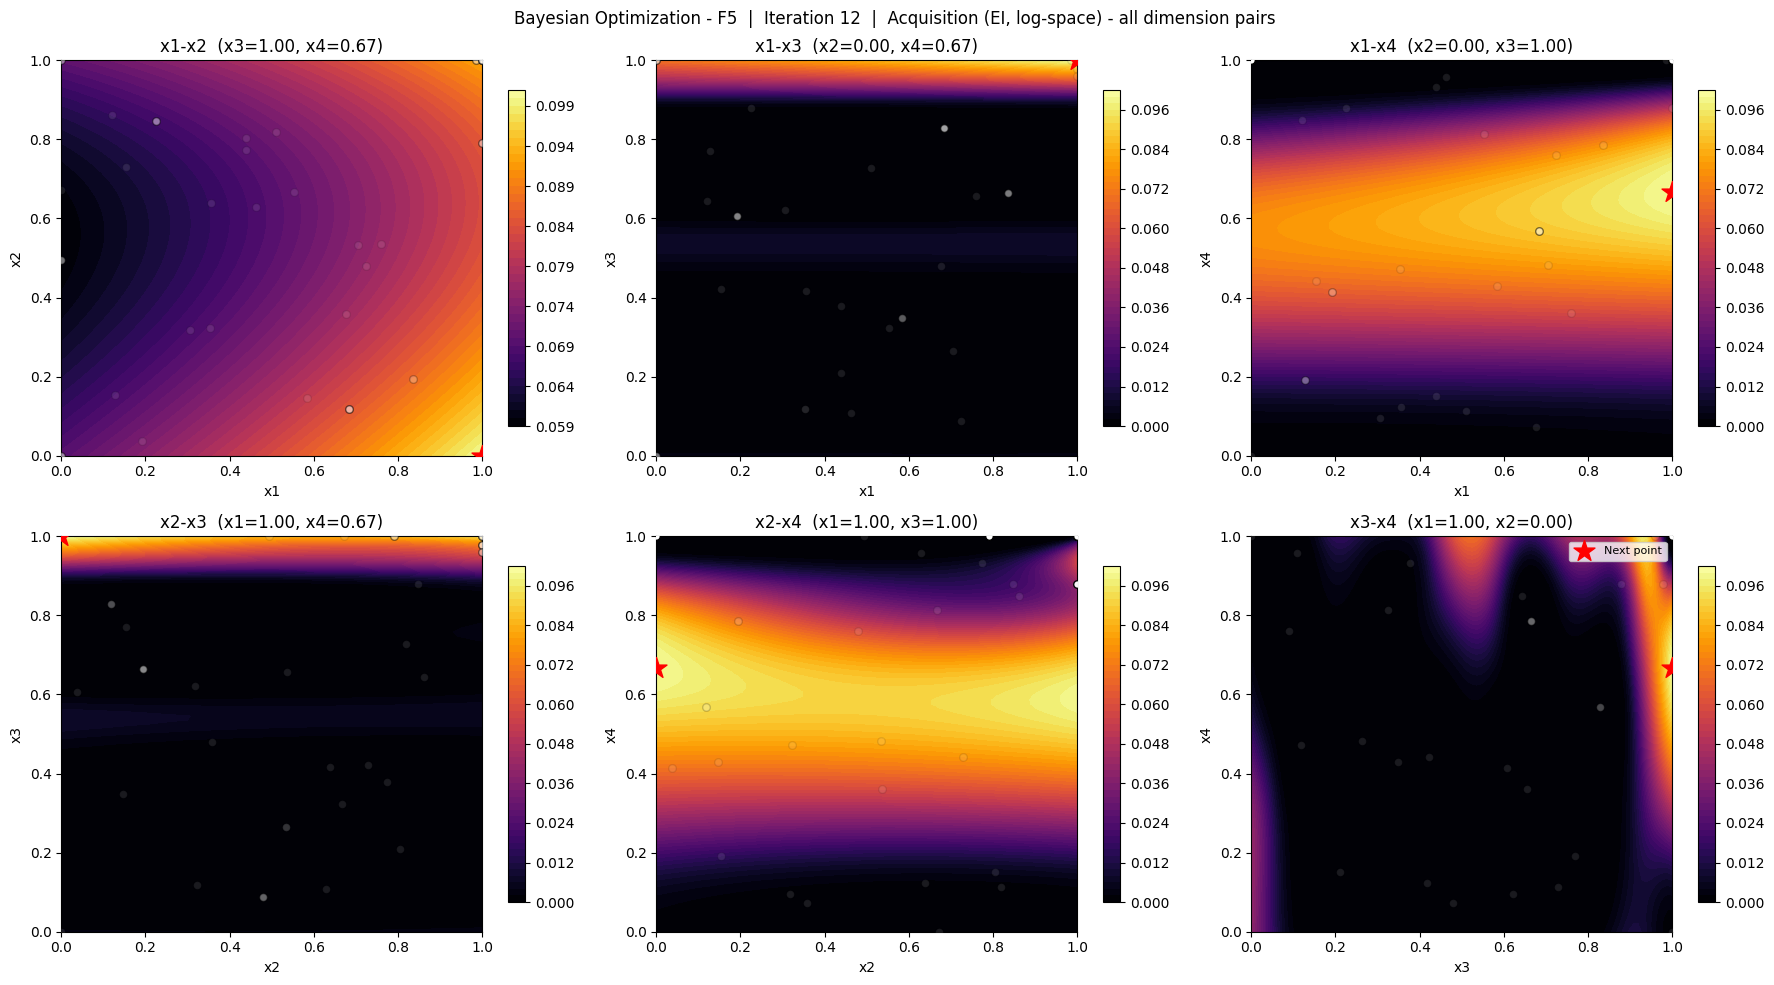

In [7]:
# ── Past Week Data ─────────────────────────────────────────────────────────────
X_new_Data = np.array([]).reshape(0, 4)
y_new_Data = np.array([])

# Week1 addition
X_new_Data = np.vstack([X_new_Data, [0.000000, 0.999999, 0.999999, 0.999999]])
y_new_Data = np.hstack([y_new_Data, 4440.480873479282])

# Week2 addition
X_new_Data = np.vstack([X_new_Data, [0.000000, 0.000000, 0.000000, 0.999999]])
y_new_Data = np.hstack([y_new_Data, 190.83962285513473])

# Week3 addition
X_new_Data = np.vstack([X_new_Data, [0.000000, 0.494051, 0.999999, 0.999999]])
y_new_Data = np.hstack([y_new_Data, 1754.1671506887403])

# Week4 addition
X_new_Data = np.vstack([X_new_Data, [0.000000, 0.671046, 1.000000, 0.000000]])
y_new_Data = np.hstack([y_new_Data, 372.40938138106065])

# Week5 addition
X_new_Data = np.vstack([X_new_Data, [1.000000, 1.000000, 1.000000, 1.000000]])
y_new_Data = np.hstack([y_new_Data, 8662.4825])

# Week6 addition
X_new_Data = np.vstack([X_new_Data, [0.986626, 1.000000, 1.000000, 1.000000]])
y_new_Data = np.hstack([y_new_Data, 8410.305682352177])

# Week7 addition
X_new_Data = np.vstack([X_new_Data, [0.000000, 0.000000, 1.000000, 1.000000]])
y_new_Data = np.hstack([y_new_Data, 1616.6425])

# Week8 addition
X_new_Data = np.vstack([X_new_Data, [1.000000, 0.790751, 1.000000, 1.000000]])
y_new_Data = np.hstack([y_new_Data, 5951.8993792538495])

# Week9 addition
X_new_Data = np.vstack([X_new_Data, [1.000000, 1.000000, 0.978264, 0.878994]])
y_new_Data = np.hstack([y_new_Data, 6458.725881969724])

# Week10 addition
X_new_Data = np.vstack([X_new_Data, [1.000000, 1.000000, 0.960172, 1.000000]])
y_new_Data = np.hstack([y_new_Data, 7950.351175594969])

# Week12 addition
X_new_Data = np.vstack([X_new_Data, [1.000000, 0.000000, 1.000000, 1.000000]])
y_new_Data = np.hstack([y_new_Data, 4440.5225])

# ── Configuration ─────────────────────────────────────────────────────────────
N_ITER   = len(y_new_Data)+1       # number of BO steps to run
ACQ      = "ei"    # "ei" or "ucb"
XI_INIT  = 0.1     # matches original F5 xi
XI_DECAY = 0.85
KAPPA    = 2.576   # only used if ACQ = "ucb"

# ── History (seeded with initial observations in log-space) ───────────────────
X_obs        = X.copy()
y_obs_log    = y_log.copy()
history_best_log = [y_obs_log.max()]
history_best_raw = [y.max()]

for iteration in range(N_ITER):

    # 1. Fit GP on log-transformed outputs
    gp        = build_gp(n_dim)
    gp.fit(X_obs, y_obs_log)
    y_max_log = y_obs_log.max()

    # 2. Compute adaptive xi for this iteration
    xi = adaptive_xi(iteration, xi_init=XI_INIT, decay=XI_DECAY)

    # 3. Define acquisition callable for the plot helper
    if ACQ == "ucb":
        acq_fn    = lambda X_c: upper_confidence_bound(X_c, gp, kappa=KAPPA)
        acq_label = "UCB"
    else:
        acq_fn    = lambda X_c: expected_improvement(X_c, gp, y_max_log, xi=xi)
        acq_label = "EI"

    # 4. Suggest next point
    x_next, score = suggest_next_point(
        gp, y_max_log, n_dim,
        xi=xi, acq=ACQ, kappa=KAPPA,
        seed=SEED + iteration
    )

    # 5. Print summary (show both log-space and raw-space best for clarity)
    print("\n" + "="*62)
    print(f"  Iteration {iteration + 1:>3d}  |  xi = {xi:.5f}  |  acq = {acq_label}")
    print(f"  Current best y (log)          : {y_max_log:.6f}")
    print(f"  ✅ Suggested x CAPSTONE       : {np.round(x_next[0], 6)}-{np.round(x_next[1], 6)}-{np.round(x_next[2], 6)}-{np.round(x_next[3], 6)}")
    print(f"  🎯 Suggested x                : {np.round(x_next, 6).tolist()}")
    print(f"  📈 Acq. score                 : {score:.6f}")
    print("="*62)

    # 6. Visualise acquisition slices — all 6 dimension pairs
    plot_slices_4d(gp, X_obs, x_next, acq_fn,
                   iteration=iteration + 1, acq_label=acq_label)

    # ── PAST WEEKS DATA ──────────────────────────────────────────────
    if iteration < len(y_new_Data):
        y_new = y_new_Data[iteration]
        y_new_log = np.log(y_new)
        X_obs = np.vstack([X_obs, X_new_Data[iteration]])
        y_obs_log = np.append(y_obs_log, y_new_log)
        history_best_log.append(y_obs_log.max())
        history_best_raw.append(np.exp(y_obs_log.max()))
    # ─────────────────────────────────────────────────────────────────────────

## 8. SVM classifier on observed data

In [8]:
# Threshold: top 25% of log-transformed observations = "high"
threshold = np.percentile(y_obs_log, 75)
labels = (y_obs_log >= threshold).astype(int)  # 1 = high, 0 = low

print(f"Threshold (75th pct, log-space): {threshold:.4f}")
print(f"High-performing points : {labels.sum()} / {len(labels)}")

# Scale inputs (SVM is sensitive to scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_obs)

# Soft-margin SVM with RBF kernel (handles non-linear boundaries)
# C controls margin softness: lower C = wider margin, more generalisation
# gamma='scale' = 1/(n_features * X.var()), a robust default
svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
svm.fit(X_scaled, labels)

print(f"\nSVM kernel  : {svm.kernel}")
print(f"Support vectors : {svm.n_support_} (class 0 / class 1)")

Threshold (75th pct, log-space): 7.4289
High-performing points : 8 / 31

SVM kernel  : rbf
Support vectors : [11  5] (class 0 / class 1)


## 9. Visualise the SVM decision boundary alongside GP

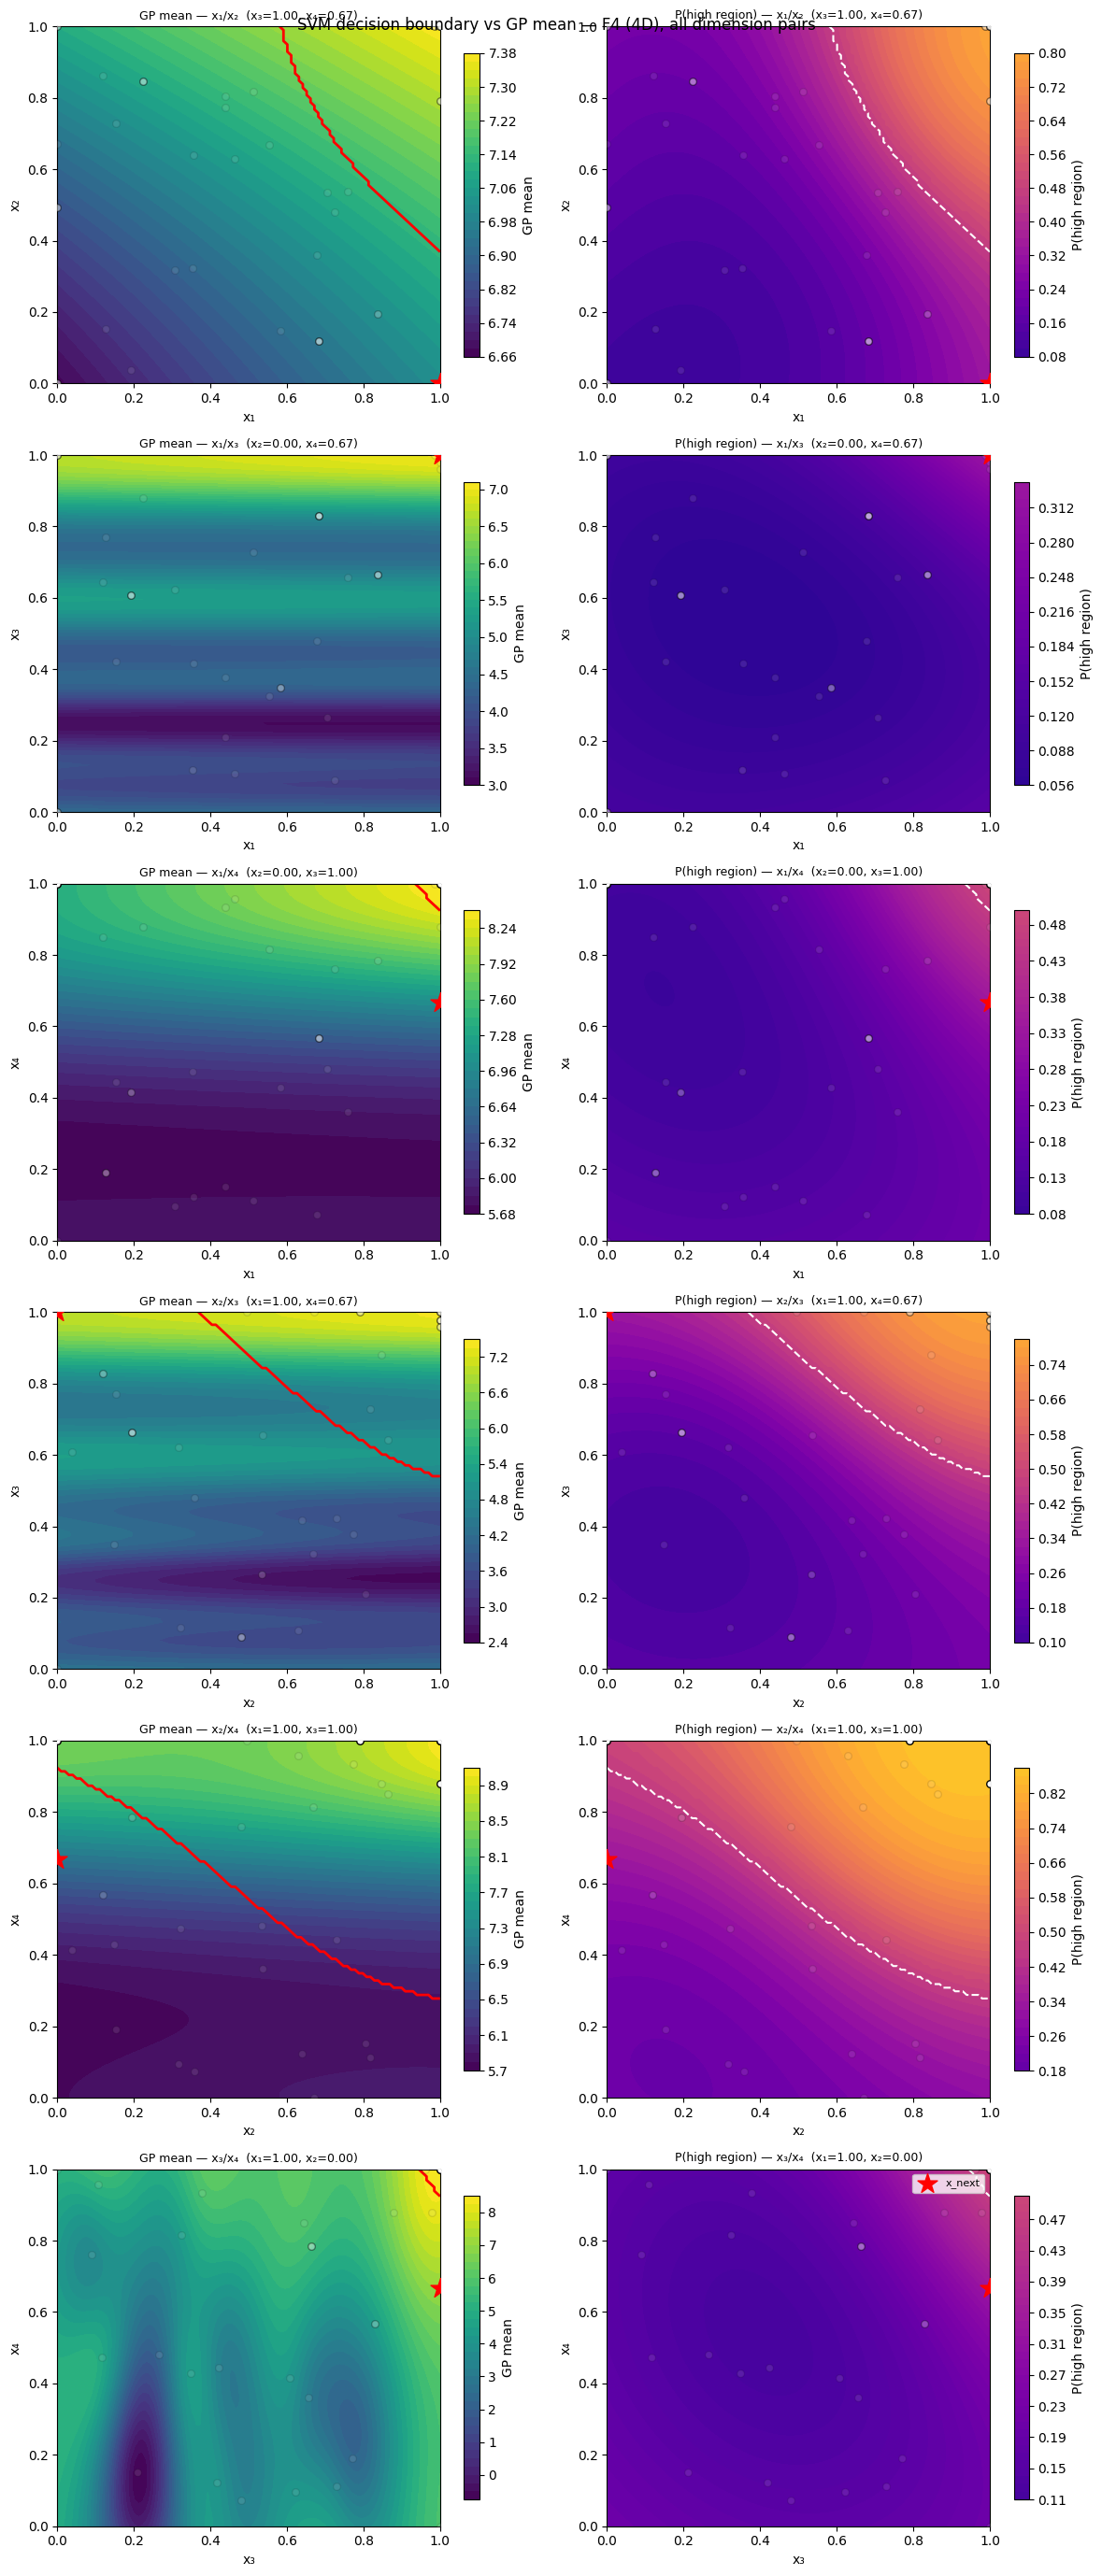

In [9]:
# ── Plot: SVM probability slices — all 6 dimension pairs (4D) ────────────────
from itertools import combinations

resolution = 100
grid_1d    = np.linspace(0, 1, resolution)
G1, G2     = np.meshgrid(grid_1d, grid_1d)
flat1, flat2 = G1.ravel(), G2.ravel()

dim_labels = ["x₁", "x₂", "x₃", "x₄"]
dim_pairs  = list(combinations(range(4), 2))   # 6 pairs

fig, axes = plt.subplots(6, 2, figsize=(12, 28))  # 6 rows × 2 cols
fig.suptitle("SVM decision boundary vs GP mean — F4 (4D), all dimension pairs", fontsize=12)

for row, (d0, d1) in enumerate(dim_pairs):
    fixed_dims = [d for d in range(4) if d not in (d0, d1)]

    # Build 4-column grid: sweep d0 & d1, fix the other two at x_next values
    X_grid = np.tile(x_next, (resolution * resolution, 1))
    X_grid[:, d0] = flat1
    X_grid[:, d1] = flat2

    # GP mean
    mu_slice, _ = gp.predict(X_grid, return_std=True)
    mu_slice     = mu_slice.reshape(resolution, resolution)

    # SVM predictions
    X_grid_scaled  = scaler.transform(X_grid)
    svm_prob_slice = svm.predict_proba(X_grid_scaled)[:, 1].reshape(resolution, resolution)
    svm_pred_slice = svm.predict(X_grid_scaled).reshape(resolution, resolution)

    # Opacity: average proximity across both fixed dims
    dist   = np.mean([np.abs(X_obs[:, fd] - x_next[fd]) for fd in fixed_dims], axis=0)
    alphas = np.clip(1.0 - dist / 0.3, 0.1, 1.0)
    fix_str = ", ".join(f"{dim_labels[fd]}={x_next[fd]:.2f}" for fd in fixed_dims)

    # Left column: GP mean + SVM boundary
    ax = axes[row, 0]
    im = ax.contourf(G1, G2, mu_slice, levels=40, cmap="viridis")
    fig.colorbar(im, ax=ax, shrink=0.85, label="GP mean")
    ax.contour(G1, G2, svm_pred_slice, levels=[0.5], colors="red", linewidths=2)
    for xi_obs, yi_obs, a in zip(X_obs[:, d0], X_obs[:, d1], alphas):
        ax.scatter(xi_obs, yi_obs, c="white", edgecolors="black",
                   s=30, alpha=float(a), zorder=5)
    ax.scatter(x_next[d0], x_next[d1], c="red", marker="*", s=250, zorder=6)
    ax.set_title(f"GP mean — {dim_labels[d0]}/{dim_labels[d1]}  ({fix_str})", fontsize=9)
    ax.set_xlabel(dim_labels[d0]); ax.set_ylabel(dim_labels[d1])

    # Right column: SVM P(high)
    ax = axes[row, 1]
    im2 = ax.contourf(G1, G2, svm_prob_slice, levels=40, cmap="plasma", vmin=0, vmax=1)
    fig.colorbar(im2, ax=ax, shrink=0.85, label="P(high region)")
    ax.contour(G1, G2, svm_pred_slice, levels=[0.5], colors="white",
               linewidths=1.5, linestyles="--")
    for xi_obs, yi_obs, a in zip(X_obs[:, d0], X_obs[:, d1], alphas):
        ax.scatter(xi_obs, yi_obs, c="white", edgecolors="black",
                   s=30, alpha=float(a), zorder=5)
    ax.scatter(x_next[d0], x_next[d1], c="red", marker="*", s=250,
               zorder=6, label="x_next")
    ax.set_title(f"P(high region) — {dim_labels[d0]}/{dim_labels[d1]}  ({fix_str})", fontsize=9)
    ax.set_xlabel(dim_labels[d0]); ax.set_ylabel(dim_labels[d1])

axes[-1, 1].legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig("svm_boundary_f4.png", dpi=150)
plt.show()

## 10. SVM-constrained next point suggestion

In [10]:
# ── Constrained BO: suggest next point inside SVM "high" region ──────────────
from scipy.stats import qmc

# Generate a large Sobol candidate set
sampler = qmc.Sobol(d=n_dim, scramble=True, seed=SEED + 99)
X_cand = sampler.random(20_000)

# Keep only candidates the SVM classifies as "high"
X_cand_scaled = scaler.transform(X_cand)
svm_labels    = svm.predict(X_cand_scaled)
svm_probs     = svm.predict_proba(X_cand_scaled)[:, 1]

# Filter: inside SVM high region AND probability > 0.5
mask = (svm_labels == 1) & (svm_probs > 0.5)
X_constrained = X_cand[mask]

print(f"Candidates in high region : {mask.sum()} / {len(X_cand)} "
      f"({100*mask.mean():.1f}% of space)")

if len(X_constrained) < 10:
    # Fallback: boundary too restrictive, use full candidate set
    print("⚠️  Fewer than 10 constrained candidates — falling back to full set.")
    X_constrained = X_cand

# Score with EI inside the constrained region only
xi_constrained = adaptive_xi(N_ITER, xi_init=XI_INIT, decay=XI_DECAY)
ei_scores = expected_improvement(X_constrained, gp, y_obs_log.max(), xi=xi_constrained)

# Local optimisation from top-8 starts within the constrained region
starts = X_constrained[np.argsort(ei_scores)[-8:]]
bounds = [(0, 1)] * n_dim
obj    = lambda x: -expected_improvement(x, gp, y_obs_log.max(), xi=xi_constrained).item()

best_x_svm, best_score_svm = None, -np.inf
for x0 in starts:
    res = minimize(obj, x0=x0, bounds=bounds, method="L-BFGS-B")
    if -res.fun > best_score_svm:
        best_score_svm = -res.fun
        best_x_svm     = res.x

print(f"\n{'='*55}")
print(f"  SVM-constrained suggestion")
print(f"  Suggested x : {np.round(best_x_svm, 6).tolist()}")
print(f"  EI score    : {best_score_svm:.6f}")
print(f"  xi used     : {xi_constrained:.5f}")
print(f"  ✅ CAPSTONE format : {np.round(best_x_svm[0],6)}-{np.round(best_x_svm[1],6)}-{np.round(best_x_svm[2],6)}-{np.round(best_x_svm[3],6)}")
print(f"{'='*55}")

C:\Users\fakep\AppData\Local\Temp\ipykernel_27236\4044531684.py:6: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand = sampler.random(20_000)


Candidates in high region : 347 / 20000 (1.7% of space)

  SVM-constrained suggestion
  Suggested x : [1.0, 1.0, 1.0, 0.592052]
  EI score    : 0.099620
  xi used     : 0.01422
  ✅ CAPSTONE format : 1.0-1.0-1.0-0.592052


## 11. Neural Network Surrogate (MC Dropout)

We use a **PyTorch MLP with Monte Carlo Dropout** as a third surrogate. Unlike the GP (which has a closed-form posterior) or the SVM (which only classifies regions), the NN learns a direct regression mapping from input to output.

**Why MC Dropout for uncertainty?**
Dropout randomly zeroes neurons during training to prevent co-adaptation. At inference time, keeping dropout *active* and running multiple forward passes produces a distribution of predictions — the mean is the surrogate's prediction and the standard deviation is its uncertainty estimate (Gal & Ghahramani, 2016).

**Architecture:**
- 2 hidden layers of 32 units with ReLU activations
- Dropout rate = 0.1 between each layer
- Trained with Adam + L2 weight decay on normalised targets
- Uncertainty = std across 200 stochastic forward passes

> **F5 note:** Like the GP, the NN trains on **log-transformed outputs** (`y_obs_log`). EI is computed in log-space using `y_obs_log.max()` as the incumbent — this is consistent with the GP's acquisition function and keeps the comparison fair.

In [11]:
class MCDropoutNN(nn.Module):
    """MLP with dropout kept active at inference for uncertainty quantification."""

    def __init__(self, n_in, hidden=32, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

    def mc_predict(self, x_tensor, n_samples=200):
        """n_samples stochastic forward passes → (mean, std) as numpy arrays."""
        self.train()   # keep dropout active during inference
        with torch.no_grad():
            preds = torch.stack([self(x_tensor) for _ in range(n_samples)])
        return preds.mean(0).numpy(), preds.std(0).numpy()


# ── Normalise inputs and log-transformed targets ──────────────────────────────
scaler_nn = StandardScaler()
X_nn      = scaler_nn.fit_transform(X_obs)

y_nn_mean = y_obs_log.mean()
y_nn_std  = max(y_obs_log.std(), 1e-8)
y_nn      = (y_obs_log - y_nn_mean) / y_nn_std   # N(0,1) targets in log-space

X_t = torch.tensor(X_nn, dtype=torch.float32)
y_t = torch.tensor(y_nn, dtype=torch.float32)

# ── Train ─────────────────────────────────────────────────────────────────────
torch.manual_seed(SEED)
nn_model  = MCDropoutNN(n_dim, hidden=32, dropout=0.1)
optimizer = optim.Adam(nn_model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn   = nn.MSELoss()

nn_model.train()
for epoch in range(3000):
    optimizer.zero_grad()
    loss = loss_fn(nn_model(X_t), y_t)
    loss.backward()
    optimizer.step()

print(f"NN trained — final MSE loss: {loss.item():.6f}")

# ── Sanity check on training data ─────────────────────────────────────────────
mu_chk, sig_chk = nn_model.mc_predict(X_t, n_samples=200)
mu_chk_log = mu_chk * y_nn_std + y_nn_mean
print(f"NN mean pred range (log) : [{mu_chk_log.min():.3f}, {mu_chk_log.max():.3f}]")
print(f"NN uncertainty std range : [{sig_chk.min():.4f},  {sig_chk.max():.4f}]")

NN trained — final MSE loss: 0.014077
NN mean pred range (log) : [-1.792, 8.915]
NN uncertainty std range : [0.0343,  0.3748]


## 12. NN-constrained next point suggestion

We define EI using the MC-Dropout NN's predicted mean (μ) and standard deviation (σ) — both in **log-space**, consistent with the GP. We use 65,536 Sobol candidates (2^16, power-of-2 for 4D) and 12 L-BFGS-B restarts.

In [12]:
def expected_improvement_nn(X_cand, nn_model, scaler_nn, y_nn_mean, y_nn_std,
                             y_max_log, xi=0.01, n_mc=200):
    """EI using MC-Dropout NN surrogate — all quantities in log-space."""
    X_cand   = np.atleast_2d(X_cand)
    X_scaled = scaler_nn.transform(X_cand)
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    mu_norm, sigma_norm = nn_model.mc_predict(X_tensor, n_samples=n_mc)
    # Un-normalise back to log-space
    mu    = mu_norm  * y_nn_std + y_nn_mean
    sigma = np.maximum(sigma_norm * y_nn_std, 1e-8)
    imp   = mu - y_max_log - xi
    Z     = imp / sigma
    ei    = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma <= 1e-8] = 0.0
    return ei


xi_nn = adaptive_xi(N_ITER, xi_init=XI_INIT, decay=XI_DECAY)

# Sobol candidates — 65,536 (2^16), power-of-2 for 4D
sampler_nn   = qmc.Sobol(d=n_dim, scramble=True, seed=SEED + 199)
X_cand_nn    = sampler_nn.random(65_536)

ei_nn_scores = expected_improvement_nn(
    X_cand_nn, nn_model, scaler_nn, y_nn_mean, y_nn_std, y_obs_log.max(), xi=xi_nn
)

# Local optimisation from top-12 Sobol starts (matches GP's n_best for 4D)
starts_nn = X_cand_nn[np.argsort(ei_nn_scores)[-12:]]
obj_nn    = lambda x: -expected_improvement_nn(
    x, nn_model, scaler_nn, y_nn_mean, y_nn_std, y_obs_log.max(), xi=xi_nn
).item()

best_x_nn, best_score_nn = None, -np.inf
for x0 in starts_nn:
    res = minimize(obj_nn, x0=x0, bounds=[(0, 1)] * n_dim, method="L-BFGS-B")
    if -res.fun > best_score_nn:
        best_score_nn = -res.fun
        best_x_nn     = res.x

print(f"\n{'='*65}")
print(f"  NN (MC Dropout) suggestion")
print(f"  Suggested x : {np.round(best_x_nn, 6).tolist()}")
print(f"  EI score    : {best_score_nn:.6f}")
print(f"  xi used     : {xi_nn:.5f}")
print(f"  ✅ CAPSTONE format : {np.round(best_x_nn[0],6)}-{np.round(best_x_nn[1],6)}-{np.round(best_x_nn[2],6)}-{np.round(best_x_nn[3],6)}")
print(f"{'='*65}")


  NN (MC Dropout) suggestion
  Suggested x : [0.989082, 0.988896, 0.997647, 0.900145]
  EI score    : 0.038164
  xi used     : 0.01422
  ✅ CAPSTONE format : 0.989082-0.988896-0.997647-0.900145


## 13. Visualise the NN surrogate surface (4D slices, log-space)

Six panels show the **NN EI surface** across all 6 dimension pairs — mirroring the GP acquisition plot in Section 6. EI values are in log-space, consistent with how the GP and NN were both fitted.

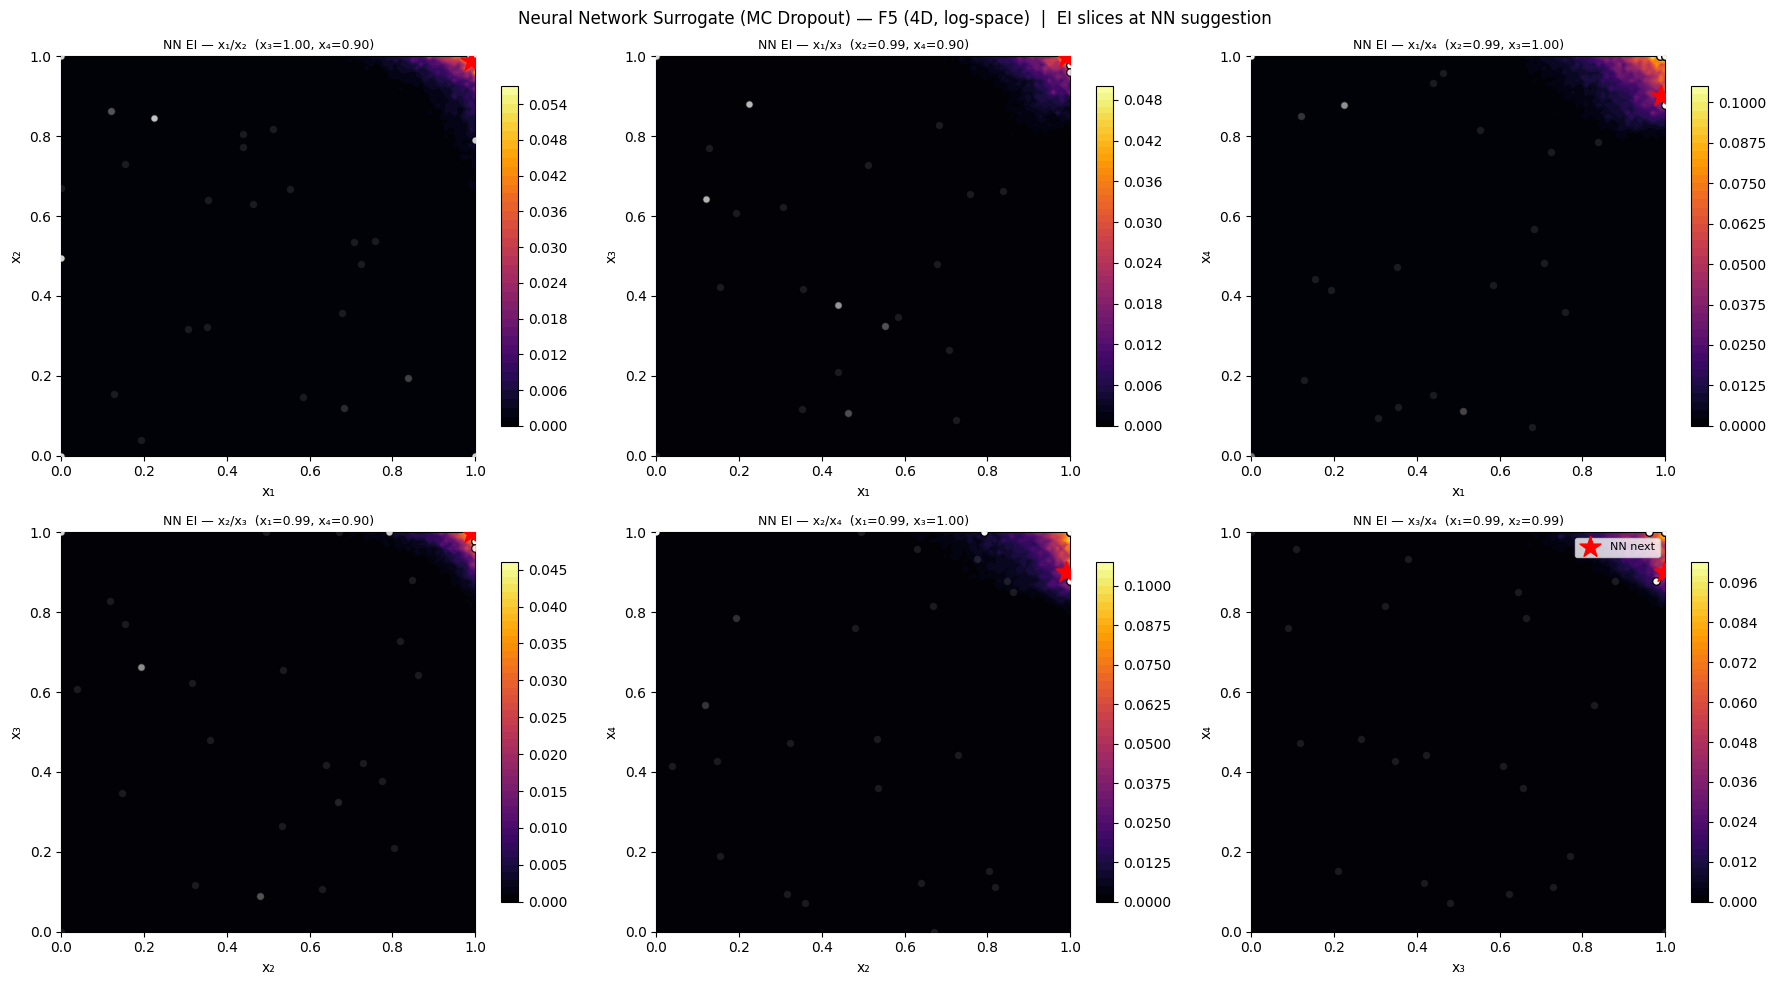

In [13]:
resolution = 100
grid_1d    = np.linspace(0, 1, resolution)
G1, G2     = np.meshgrid(grid_1d, grid_1d)
flat1, flat2 = G1.ravel(), G2.ravel()

dim_labels = ["x₁", "x₂", "x₃", "x₄"]
dim_pairs  = list(combinations(range(4), 2))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat  = axes.ravel()
fig.suptitle(
    "Neural Network Surrogate (MC Dropout) — F5 (4D, log-space)  |  EI slices at NN suggestion",
    fontsize=12
)

for ax, (d0, d1) in zip(axes_flat, dim_pairs):
    fixed_dims = [d for d in range(4) if d not in (d0, d1)]

    X_grid        = np.tile(best_x_nn, (resolution * resolution, 1))
    X_grid[:, d0] = flat1
    X_grid[:, d1] = flat2

    ei_vals = expected_improvement_nn(
        X_grid, nn_model, scaler_nn, y_nn_mean, y_nn_std, y_obs_log.max(), xi=xi_nn, n_mc=200
    ).reshape(resolution, resolution)

    im = ax.contourf(G1, G2, ei_vals, levels=50, cmap="inferno")
    fig.colorbar(im, ax=ax, shrink=0.85)

    dist   = np.mean([np.abs(X_obs[:, fd] - best_x_nn[fd]) for fd in fixed_dims], axis=0)
    alphas = np.clip(1.0 - dist / 0.3, 0.1, 1.0)
    for xi_o, yi_o, a in zip(X_obs[:, d0], X_obs[:, d1], alphas):
        ax.scatter(xi_o, yi_o, c="white", edgecolors="black",
                   s=30, alpha=float(a), zorder=5)

    ax.scatter(best_x_nn[d0], best_x_nn[d1], c="red", marker="*",
               s=250, zorder=6, label="NN next")

    fix_str = ", ".join(f"{dim_labels[fd]}={best_x_nn[fd]:.2f}" for fd in fixed_dims)
    ax.set_title(f"NN EI — {dim_labels[d0]}/{dim_labels[d1]}  ({fix_str})", fontsize=9)
    ax.set_xlabel(dim_labels[d0]); ax.set_ylabel(dim_labels[d1])

axes_flat[-1].legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig("nn_surrogate_f5.png", dpi=150)
plt.show()

## 14. Compare all three models: GP vs SVM vs NN

We compare the **EI score** and **suggested next point** from each surrogate:

| Model | Surrogate type | Uncertainty source | Space |
|---|---|---|---|
| **GP** | Matérn 5/2 kernel | Bayesian posterior (exact) | log |
| **SVM** | RBF classifier | P(high region) — filters candidates | log |
| **NN** | MC-Dropout MLP | 200 stochastic forward passes | log |

All three models operate in **log-space** — EI scores are directly comparable.

Model                                                           Suggested x   EI (log-space)
----------------------------------------------------------------------------------------------
GP (unconstrained)                                 [1.0, 0.0, 1.0, 0.66768]         0.100396
SVM-constrained                                   [1.0, 1.0, 1.0, 0.592052]         0.099620
NN (MC Dropout)                    [0.989082, 0.988896, 0.997647, 0.900145]         0.038164

GP  ↔ SVM distance : 1.0029
GP  ↔ NN  distance : 1.0159
SVM ↔ NN  distance : 0.3085

❗ Strong disagreement — models see different promising regions; trust the GP.


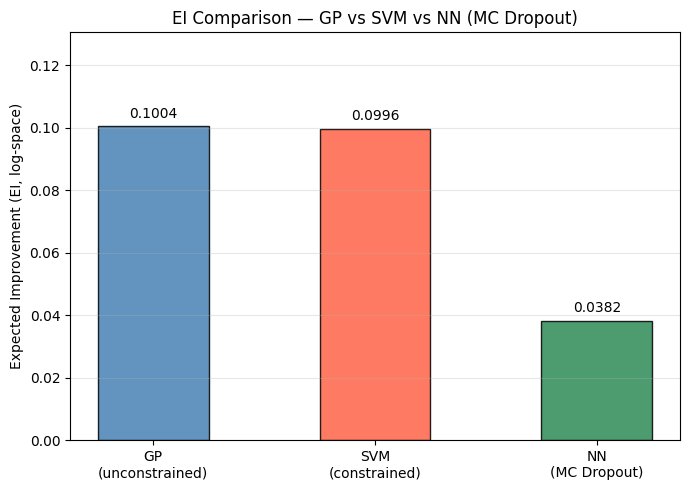

In [14]:
# ── Summary table ─────────────────────────────────────────────────────────────
print(f"{'Model':<24} {'Suggested x':>50}   {'EI (log-space)':>14}")
print("-" * 94)
print(f"{'GP (unconstrained)':<24} {str(np.round(x_next, 6).tolist()):>50}   {score:>14.6f}")
print(f"{'SVM-constrained':<24} {str(np.round(best_x_svm, 6).tolist()):>50}   {best_score_svm:>14.6f}")
print(f"{'NN (MC Dropout)':<24} {str(np.round(best_x_nn, 6).tolist()):>50}   {best_score_nn:>14.6f}")

# ── Pairwise distances ────────────────────────────────────────────────────────
dist_gp_svm = np.linalg.norm(x_next - best_x_svm)
dist_gp_nn  = np.linalg.norm(x_next - best_x_nn)
dist_svm_nn = np.linalg.norm(best_x_svm - best_x_nn)

print(f"\nGP  ↔ SVM distance : {dist_gp_svm:.4f}")
print(f"GP  ↔ NN  distance : {dist_gp_nn:.4f}")
print(f"SVM ↔ NN  distance : {dist_svm_nn:.4f}")

# ── Consensus check ───────────────────────────────────────────────────────────
suggestions = [x_next, best_x_svm, best_x_nn]
centroid    = np.mean(suggestions, axis=0)
max_dev     = max(np.linalg.norm(s - centroid) for s in suggestions)

if max_dev < 0.05:
    print("\n✅ All three models agree — very high confidence in this region.")
elif max_dev < 0.15:
    print("\n⚠️  Mild disagreement — GP posterior is most principled; prefer GP suggestion.")
else:
    print("\n❗ Strong disagreement — models see different promising regions; trust the GP.")

# ── Bar chart: EI scores across the three surrogates ─────────────────────────
labels_bar    = ["GP\n(unconstrained)", "SVM\n(constrained)", "NN\n(MC Dropout)"]
ei_scores_bar = [score, best_score_svm, best_score_nn]
colors_bar    = ["steelblue", "tomato", "seagreen"]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels_bar, ei_scores_bar, color=colors_bar,
              edgecolor="black", alpha=0.85, width=0.5)
ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=10)
ax.set_ylabel("Expected Improvement (EI, log-space)")
ax.set_title("EI Comparison — GP vs SVM vs NN (MC Dropout)")
ax.set_ylim(0, max(ei_scores_bar) * 1.3)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("ei_comparison_three_models_f5.png", dpi=150)
plt.show()

## 15. Hyperparameter Sensitivity — ξ (xi) Exploration (Module 18)

Module 18 identifies **ξ (xi)** as the key hyperparameter of the EI acquisition function controlling the exploration–exploitation trade-off. Rather than relying solely on the adaptive decay schedule, this section applies a **coarse grid search** over ξ — the simplest tuning strategy from Mini-lesson 18.5.

By scanning ξ ∈ {0.001 … 0.5} with the GP already fitted on all 4D observations, we can:
- Confirm the adaptive ξ is in a sensible range for the current dataset
- See how sensitive the suggested query is to this hyperparameter
- Decide whether to override the schedule if the function appears nearly converged (small ξ) or still widely uncertain (large ξ)

In [15]:
# ── ξ (xi) grid search — treating xi as a hyperparameter to tune ──────────────────
print('GP suggestion sensitivity to xi (exploration-exploitation hyperparameter):')
print(f"{'xi':>8}  {'EI score':>12}  Suggested x (CAPSTONE format)")
print('-' * 85)

xi_grid    = [0.001, 0.01, 0.05, 0.1, 0.5]
xi_current = adaptive_xi(N_ITER, xi_init=XI_INIT, decay=XI_DECAY)

for xi_test in xi_grid:
    sampler_s  = qmc.Sobol(d=n_dim, scramble=True, seed=SEED + 888)
    X_c_s      = sampler_s.random(8_192)          # 2^13 quick scan
    scores_s   = expected_improvement(X_c_s, gp, y_obs_log.max(), xi=xi_test)
    starts_s   = X_c_s[np.argsort(scores_s)[-5:]]
    obj_s      = lambda x, xi=xi_test: -expected_improvement(x, gp, y_obs_log.max(), xi=xi).item()
    bx_s, bs_s = None, -np.inf
    for x0 in starts_s:
        r = minimize(obj_s, x0=x0, bounds=[(0, 1)] * n_dim, method='L-BFGS-B')
        if -r.fun > bs_s: bs_s = -r.fun; bx_s = r.x
    capstone_s = '-'.join(f'{v:.6f}' for v in bx_s)
    marker     = '  <- adaptive (current)' if abs(xi_test - xi_current) < 0.02 else ''
    print(f'  {xi_test:>6.3f}  {bs_s:>12.6f}  {capstone_s}{marker}')

print(f'\nAdaptive xi at iteration {N_ITER}: {xi_current:.5f}  '
      f'(xi_init={XI_INIT}, decay={XI_DECAY}^{N_ITER})')

GP suggestion sensitivity to xi (exploration-exploitation hyperparameter):
      xi      EI score  Suggested x (CAPSTONE format)
-------------------------------------------------------------------------------------
   0.001      0.102262  1.000000-0.000000-1.000000-0.669670  <- adaptive (current)
   0.010      0.101190  1.000000-0.000000-1.000000-0.668527  <- adaptive (current)
   0.050      0.096560  1.000000-0.000000-1.000000-0.663586
   0.100      0.091064  1.000000-0.000000-1.000000-0.657699
   0.500      0.056664  1.000000-0.000000-1.000000-0.619466

Adaptive xi at iteration 12: 0.01422  (xi_init=0.1, decay=0.85^12)


## 16. GP Kernel Diagnostics (Module 18)

The GP kernel hyperparameters are fitted by maximising the log-marginal-likelihood. Inspecting them connects to Module 18's insight that **length scales act as feature importance scores**:

- **Small length scale** → function changes quickly along that axis → high sensitivity → important dimension
- **Large length scale** → function is nearly flat along that axis → low sensitivity → potentially irrelevant

This mirrors Module 18's note that random search works well when only a few hyperparameters heavily influence performance — the same may be true of our 4D function's input dimensions. A large length-scale disparity is a signal to focus future queries on the most sensitive dimensions.

Fitted GP kernel hyperparameters (F5, 4D):
  Amplitude  s2   : 0.8758
  Noise level     : 3.31e-05

Per-dimension length scales:
  x1:    5.1401  XXXXXXXXXXXXXXX
  x2:    1.7689  XXXXXXXXXXXXX
  x3:    0.1039  XXXXXXX
  x4:    0.3211  XXXXXXXXX

Most  sensitive dim : x3 (ls=0.1039)
Least sensitive dim : x1 (ls=5.1401)

[!] Length scale ratio 49x -- function may be effectively lower-dimensional. Focus future queries around x3.


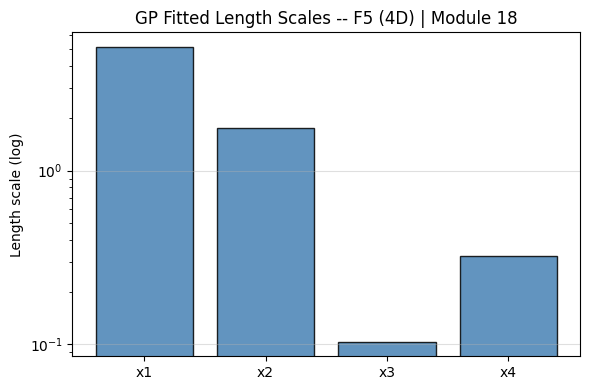

In [16]:
# ── GP fitted kernel hyperparameters ─────────────────────────────────────────────
fitted_ls = gp.kernel_.k1.k2.length_scale
noise_lv  = gp.kernel_.k2.noise_level
amplitude = gp.kernel_.k1.k1.constant_value
ls_arr    = np.array(fitted_ls)
dim_lbls  = [f'x{i+1}' for i in range(n_dim)]

print(f'Fitted GP kernel hyperparameters (F5, {n_dim}D):')
print(f'  Amplitude  s2   : {amplitude:.4f}')
print(f'  Noise level     : {noise_lv:.2e}')
print('\nPer-dimension length scales:')
for lbl, ls in zip(dim_lbls, ls_arr):
    bar = 'X' * max(1, min(int(np.log10(ls + 1e-8) * 5 + 12), 35))
    print(f'  {lbl}: {ls:9.4f}  {bar}')

if n_dim >= 3:
    idx_min, idx_max = ls_arr.argmin(), ls_arr.argmax()
    ratio = ls_arr[idx_max] / (ls_arr[idx_min] + 1e-8)
    print(f'\nMost  sensitive dim : {dim_lbls[idx_min]} (ls={ls_arr[idx_min]:.4f})')
    print(f'Least sensitive dim : {dim_lbls[idx_max]} (ls={ls_arr[idx_max]:.4f})')
    if ratio > 10:
        print(f'\n[!] Length scale ratio {ratio:.0f}x -- function may be effectively '
              f'lower-dimensional. Focus future queries around {dim_lbls[idx_min]}.')
    else:
        print(f'\n[OK] Length scale ratio {ratio:.1f}x -- all dimensions contribute similarly.')

fig, ax = plt.subplots(figsize=(max(6, n_dim * 1.3), 4))
ax.bar(dim_lbls, ls_arr, color='steelblue', edgecolor='black', alpha=0.85)
ax.set_yscale('log')
ax.set_ylabel('Length scale (log)')
ax.set_title(f'GP Fitted Length Scales -- F5 ({n_dim}D) | Module 18')
ax.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('length_scales_module18_f5.png', dpi=150)
plt.show()

## 17. Convergence Plot

After running multiple iterations with real evaluations, this cell plots the **best observed value over time** in both log-space and raw-space side by side.

For F5 both views are useful:
- **Log-space** shows the GP's internal progress smoothly
- **Raw-space** shows the actual magnitude of improvement, which can be dramatic given the large y range

Uncomment and run after completing multiple BO iterations.

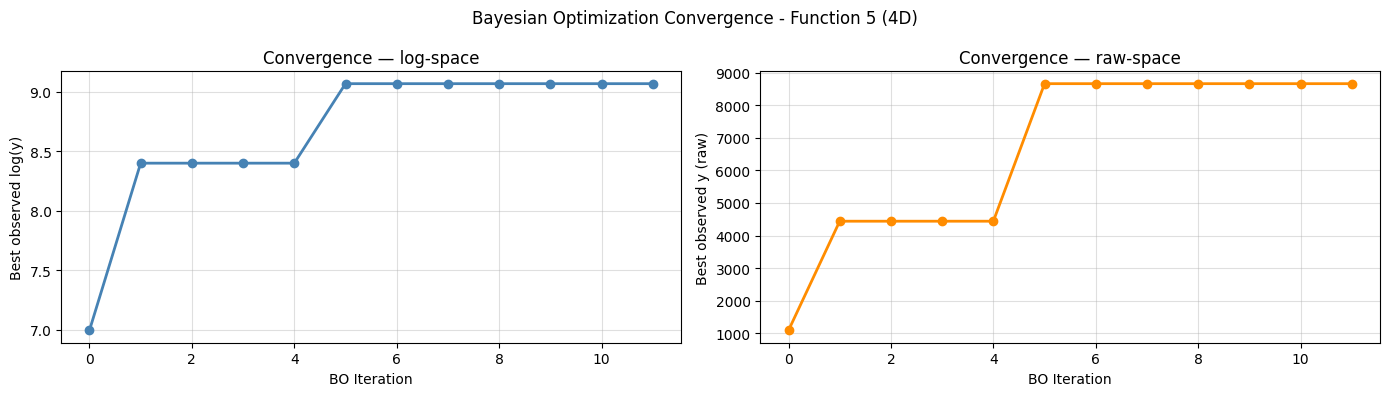

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
#
ax1.plot(range(len(history_best_log)), history_best_log, marker="o", linewidth=2, color="steelblue")
ax1.set_xlabel("BO Iteration")
ax1.set_ylabel("Best observed log(y)")
ax1.set_title("Convergence — log-space")
ax1.grid(True, alpha=0.4)
#
ax2.plot(range(len(history_best_raw)), history_best_raw, marker="o", linewidth=2, color="darkorange")
ax2.set_xlabel("BO Iteration")
ax2.set_ylabel("Best observed y (raw)")
ax2.set_title("Convergence — raw-space")
ax2.grid(True, alpha=0.4)
#
plt.suptitle("Bayesian Optimization Convergence - Function 5 (4D)", fontsize=12)
plt.tight_layout()
plt.savefig("convergence_f5.png", dpi=150)
plt.show()